# Identification of a 2-DOF Mass-Spring-Damper System with Non-proportional Damping

***

In all our system identification excercises so far, we have always considered systems with proportional damping. However, as Prof. Sam Ibrahim said, "proportional damping is like suggesting that all men are linear combinations of Robert
Redford and George Clooney." Consequently, it is clear that for the majority of real-world systems, proportional damping will not be a very accurate assumption. For this reason, in this notebook we will look at the identification of a 2-DOF mass-spring-damper system with non-proportional damping. We'll first review the theoretical background of general undamped, proportionally damped, and non-proportionally damped Multiple Degree of Freedom (MDOF) systems, in order to understand what non-proportional damping implies compared to the problems we have solved so far. Then, we will go back to our 2-DOF mass-spring-damper system and compare its behavior with proportional and non-proportional damping. Finally, we will estimate the modal parameters of the non-proportionally damped system from random excitation data, using both a fixed model order and multiple model orders.

* [Theoretical Background](#theoretical-background)
    * [Undamped MDOF System](#undamped-mdof-system)
    * [Propotional Damping](#propotional-damping)
    * [Non-proportional Damping](#non-proportional-damping)
    * [2-DOF Mass-Spring-Damper System with Non-proportional Damping](#2-dof)
* [Parameter Estimation from Random Excitation](#estimation-random)
    * [Data Generation and Processing](#data-generation-processing)
    * [Parameter Estimation with Fixed Model Order](#parameter-estimation-fixed)
    * [Parameter Estimation with Multiple Model Orders](#parameter-estimation-multiple)
* [Conclusions](#conclusions)

## Theoretical Background <a id='theoretical-background'></a>

***

### Undamped MDOF System <a id='undamped-mdof-system'></a>

The equation of motion of an undamped Linear Time-Invariant (LTI) Multi-Degree-Of-Freedom (MDOF) system with $N$ degrees of freedom is given by:

$$
\mathbf{M} \ddot{\mathbf{x}}(t) + \mathbf{K} \mathbf{x}(t) = \mathbf{f}(t),
$$

where $\mathbf{M}$ and $\mathbf{K}$ are the $N \times N$ mass and stiffness matrices, respectively, and $\mathbf{f}(t)$ and $\mathbf{x}$ are the $N \times 1$ vectors of time-varying external forces and displacements, respectively.

The free vibration solution is obtained by taking $\mathbf{F}(t) = \mathbf{0}$ and assuming a harmonic solution of the form $\mathbf{x}(t) = \mathbf{X} e^{i \omega t}$, where $\mathbf{X}$ is the displacement amplitude vector, $i$ is the imaginary unit, and $\omega$ is the angular frequency. Substituting this into the equation of motion yields:

$$
\left(\mathbf{K} - \omega^2 \mathbf{M}\right) \mathbf{X} e^{i \omega t} = \mathbf{0},
$$

for which the non-trivial solution exists only if the determinant of the matrix multiplying $\mathbf{X}$ is zero:

$$
\det\left(\mathbf{K} - \omega^2 \mathbf{M}\right) = 0.
$$

This equation is equivalent to the generalized eigenvalue problem:

$$
\left(\mathbf{K} - \omega^2 \mathbf{M}\right) \mathbf{\psi} = \mathbf{0},
$$

where $\mathbf{\psi}$ is the eigenvector associated with the eigenvalue $\omega^2$. From this equation, $N$ eigenvalues are obtained, $\left(\omega_1^2, \omega_2^2,\dots, \omega_N^2\right)$, which corresponds to the squares of the undamped system's natural frequencies. Substituting these values into the free vibration equation yields the corresponding eigenvectors $\left(\mathbf{\psi}_1, \mathbf{\psi}_2,\dots, \mathbf{\psi}_N\right)$, which are the mode shapes of the system associated to each natural frequency. As we demonstrated in [notebook 3](03_Identification_of_a_2-DOF_Mass-Spring-Damper_System_with_the_LSCE_Algorithm.ipynb), the mode shapes are are subject to an indeterminate scaling factor which does not affect the shape of the vibration mode, only its amplitude.

The mode shapes possess orthogonality properties, which can be stated as follows:

$$
\mathbf{\Psi}\mathbf{M}\mathbf{\Psi}^T = \mathbf{m}\\[1ex]
\mathbf{\Psi}\mathbf{K}\mathbf{\Psi}^T = \mathbf{k},
$$

where $\Psi$ is the matrix assembled with the $N$ column vectors of the mode shapes, and $\mathbf{m}$ and $\mathbf{k}$ are the diagonal matrices typically referred to as the modal mass and modal stiffness matrices, respectively. It should be noted that, since the mode shapes are defined up to a scaling factor, there is no unique value for the modal mass and stiffness matrices.

Among the many scaling or normalization processes of the mode shapes, mass-normalization is typically the most relevant, and it is defined as:

$$
\mathbf{\Phi}^\intercal \mathbf{M} \mathbf{\Phi} = \mathbf{I},
$$

where $\mathbf{\Phi}$ is the matrix of mass-normalized mode shapes, and $\mathbf{I}$ is the identity matrix. For the mass-normalized mode shapes, the orthogonality property for the stiffness matrix becomes:

$$
\mathbf{\Phi}^\intercal \mathbf{K} \mathbf{\Phi} = \mathbf{\lambda},
$$

where $\mathbf{\lambda}$ is the diagonal matrix of the squares of the natural frequencies, i.e., $\mathbf{\lambda} = \text{diag}\left(\omega_1^2, \omega_2^2,\dots, \omega_N^2\right)$.

For the forced response solution, we consider the case where the system is excited sinusoidally by a set of forces all at the same frequency, $\omega$, but that may have different amplitudes and phases. The forces can thus be expressed as:

$$
\mathbf{f}(t) = \mathbf{F} e^{i \omega t},
$$

and, as before, we assume a harmonic solution of the form:

$$
\mathbf{x}(t) = \mathbf{X} e^{i \omega t},
$$

where $\mathbf{F}$ and $\mathbf{X}$ are the $N \times 1$ vectors of time-independent complex amplitudes. The equation of motion can then be written as:

$$
\left(\mathbf{K} - \omega^2 \mathbf{M}\right) \mathbf{X} e^{i \omega t} = \mathbf{F} e^{i \omega t},
$$

and rearranging gives:

$$
\mathbf{X} = \left(\mathbf{K} - \omega^2 \mathbf{M}\right)^{-1} \mathbf{F}.
$$

We can then define the $N \times N$ Frequency Response Function (FRF) matrix, $\mathbf{H}(\omega)$, as:

$$
\mathbf{H}(\omega) = \left(\mathbf{K} - \omega^2 \mathbf{M}\right)^{-1},
$$

where each element $H_{jk}(\omega)$ of the matrix is the FRF from the $k$-th force to the $j$-th response:

$$
H_{jk}(\omega) = \frac{X_j}{F_k},
$$

with $F_m = 0, \; \forall m \neq k$.

Since inverting the matrix $\left(\mathbf{K} - \omega^2 \mathbf{M}\right)$ at each frequency can become computationally expensive for large systems, it is common to derive $H(\omega)$ in an alternative way, which makes use of the modal properties of the system. By inverting both sides of the FRF equation, and premultiplying and postmultiplying by the mass-normalized mode shapes, we obtain:

$$
\mathbf{\Phi}^\intercal \mathbf{H}^{-1}(\omega) \mathbf{\Phi} = \mathbf{\Phi}^\intercal \left(\mathbf{K} - \omega^2 \mathbf{M}\right) \mathbf{\Phi} = \left(\mathbf{\lambda} - \omega^2 \mathbf{I}\right),
$$

which leads to:

$$
\mathbf{H}(\omega) = \mathbf{\Phi} \left(\mathbf{\lambda} - \omega^2 \mathbf{I}\right)^{-1} \mathbf{\Phi}^\intercal.
$$

We note that $\left(\mathbf{\lambda} - \omega^2 \mathbf{I}\right)$ is a diagonal matrix, and thus its inverse is simply the reciprocal of its diagonal elements. The individual elements of the FRF matrix, $H_{jk}(\omega)$, can then be computed by multiplying the $j$-th row of $\mathbf{\Phi}$ by the reciprocal of the diagonal elements of $\left(\mathbf{\lambda} - \omega^2 \mathbf{I}\right)$, and then multiplying by the $k$-th column of $\mathbf{\Phi}^\intercal$:

$$
H_{jk}(\omega) = \sum_{r=1}^N \frac{\phi_{r,j} \phi_{r,k}}{\omega_r^2 - \omega^2} = \sum_{r=1}^N \frac{R_{r,jk}}{\omega_r^2 - \omega^2},
$$

where the summation is over the $N$ modes of the system, $\omega_r$ is the natural frequency of the $r$-th mode, and $R_{r,jk}$ is the modal constant, or residue, of the $r$-th mode for the $j$-th response and $k$-th force. The above expression can also be brought in the form of a ratio of two polynomials:

$$
H_{jk}(\omega) = \frac{a_0 + a_1 \omega^2 + \dots + a_{N-1} \omega^{2(N-1)}}{b_0 + b_1 \omega^2 + \dots + b_N \omega^{2N}}.
$$

These results remind the different forms of the trasfer function obtained for the 2-DOF mass-spring-damper system in our previous notebooks, hinting at the idea that these forms are generally valid for any LTI MDOF system.

### Propotional Damping <a id='propotional-damping'></a>

The equations of motion of a damped LTI MDOF system can be expressed as:

$$
\mathbf{M} \ddot{\mathbf{x}}(t) + \mathbf{C} \dot{\mathbf{x}}(t) + \mathbf{K} \mathbf{x}(t) = \mathbf{f}(t),
$$

where $\mathbf{C}$ is the $N \times N$ viscous damping matrix. Proportional damping is a special case of viscous damping, where the damping matrix is a linear combination of the mass and stiffness matrices:

$$
\mathbf{C} = \alpha \mathbf{M} + \beta \mathbf{K},
$$

with $\alpha$ and $\beta$ being the proportional damping coefficients. By pre- and post-multiplying the damping matrix by the eigenvector matrix of the undamped system, $\mathbf{\Psi}$, we obtain:

$$
\mathbf{\Psi}^\intercal \mathbf{C} \mathbf{\Psi} = \alpha \mathbf{\Psi}^\intercal \mathbf{M} \mathbf{\Psi} + \beta \mathbf{\Psi}^\intercal \mathbf{K} \mathbf{\Psi} = \alpha \mathbf{m} + \beta \mathbf{k} = \mathbf{c},
$$

where $\mathbf{c}$ is the diagonal matrix of the modal damping coefficients. The fact that this matrix is also diagonal means that the undamped system's mode shapes are also the eigenvectors of the damped system.

The free vibration equation of the damped system $\left(\mathbf{f}(t) = \mathbf{0}\right)$ can be brought into modal coordinates by substituting $\mathbf{x}(t) = \mathbf{\Psi} \mathbf{q}(t)$, where $\mathbf{q}(t)$ is the $N \times 1$ vector of modal coordinates, and by premultiplying the equation by $\mathbf{\Psi}^\intercal$:

$$
\mathbf{m} \ddot{\mathbf{q}}(t) + \mathbf{c} \dot{\mathbf{q}}(t) + \mathbf{k} \mathbf{q}(t) = \mathbf{0}.
$$

Given the fact that the modal mass, damping and stiffness matrices are diagonal, the above equation represents a system of $N$ uncoupled second-order ordinary differential equations of the form:

$$
m_r \ddot{q}_r(t) + c_r \dot{q}_r(t) + k_r q_r(t) = 0,
$$

where $m_r$, $c_r$ and $k_r$ are modal mass, damping and stiffness coefficients of the $r$-th mode. The solution of this equation is given by:

$$
q_r(t) = Q_r e^{s_r t},
$$

where $Q_r$ is a constant, and $s_r$ is the complex frequency of the $r$-th mode, which is given by:

$$
s_r = -\omega_r\zeta_r \pm i \omega_r\sqrt{1 - \zeta_r^2},
$$

where $\omega_r=\sqrt{\frac{k_r}{m_r}}$ is the natural frequency of the undamped system for the $r$-th mode, and $\zeta_r = \frac{c_r}{2\sqrt{m_r k_r}}$ is the modal damping ratio. The real part of $s_r$ is the decay rate of the $r$-th mode, while the imaginary part is its damped natural frequency.

For the forced response solution, we consider the same sinusoidal excitation as for the undamped system, and we follow the same steps to obtain the FRF matrix:

$$
\mathbf{H}(\omega) = \left(\mathbf{K} + i \omega \mathbf{C} - \omega^2 \mathbf{M}\right)^{-1}.
$$

Analogously to the undamped case, we can invert both sides of the FRF equation, and premultiply and postmultiply the mode shapes:

$$
\mathbf{\Psi}^\intercal \mathbf{H}^{-1}(\omega) \mathbf{\Psi} = \mathbf{\Psi}^\intercal \left(\mathbf{K} + i \omega \mathbf{C} - \omega^2 \mathbf{M}\right) \mathbf{\Psi} = \left(\mathbf{k} + i \omega \mathbf{c} - \omega^2 \mathbf{m}\right),
$$

which leads to:

$$
\mathbf{H}(\omega) = \mathbf{\Psi} \left(\mathbf{k} + i \omega \mathbf{c} - \omega^2 \mathbf{m}\right)^{-1} \mathbf{\Psi}^\intercal.
$$

The elements of the FRF matrix can be computed in a similar way as for the undamped case, leading to:

$$
H_{jk}(\omega) = \sum_{r=1}^N \frac{\psi_{r,j} \psi_{r,k}}{k_r + i \omega c_r - \omega^2 m_r} = \sum_{r=1}^N \frac{R_{r,jk}}{k_r + i \omega c_r - \omega^2 m_r}.
$$

We should notice that the last expression is analogous to the partial fraction form of the FRF that we derived for the 2-DOF mass-spring-damper system in [notebook 4](04_Identification_of_a_2-DOF_Mass-Spring-Damper_System_with_the_RFP_Method.ipynb), and that it can also be expressed as a ratio of two polynomials. As for the undamped case, this result suggests that these forms of the FRF are generally valid for any LTI MDOF system with proportional damping.

### Non-proportional Damping <a id='non-proportional-damping'></a>

When the damping matrix is not proportional, the mode shapes of the damped system are not the same as those of the undamped system, and the equations of motion cannot be decoupled into a set of independent equations in modal coordinates.

Consequently, we need to look at the general solution of the equation of motion of the damped system. Considering first the free vibration case, we can assume a solution of the form:

$$
\mathbf{x}(t) = \mathbf{X} e^{\mathbf{s} t},
$$

where $s$ is complex. Substituting this into the equation of motion yields:

$$
\left(s^2 \mathbf{M} + s \mathbf{C} + \mathbf{K}\right) \mathbf{X} = \mathbf{0},
$$

for which the non-trivial solution exists only if the determinant of the matrix multiplying $\mathbf{X}$ is zero:

$$
\det\left(s^2 \mathbf{M} + s \mathbf{C} + \mathbf{K}\right) = 0.
$$

This equation is equivalent to the following quadratic eigenvalue problem:

$$
\left(s^2 \mathbf{M} + s \mathbf{C} + \mathbf{K}\right) \mathbf{\psi} = \mathbf{0},
$$

which yields $N$ complex conjugate eigenvalue pairs, $\left(s_1, s_1^*, s_2, s_2^*, \dots, s_N, s_N^*\right)$, and $N$ corresponding complex conjugate eigenvector pairs, $\left(\mathbf{\psi}_1, \mathbf{\psi}_1^*, \mathbf{\psi}_2, \mathbf{\psi}_2^*, \dots, \mathbf{\psi}_N, \mathbf{\psi}_N^*\right)$.

Similarly to the case of proportional damping, $s$ is expressed as:

$$
s_r = -\omega_r \zeta_r \pm i \omega_r \sqrt{1 - \zeta_r^2}.
$$

However, this time, the natural frequency $\omega_r$ does not correspond to the natural frequency of the undamped system, like in the case of proportional damping.

Also the above eigensolution possesses orthogonality properties, but they are different from those of the undamped and of the proportionally damped systems. We can derive these orthogonality properties by noting that any eigenvalue/eigenvector pair satisfies the following equation:

$$
\left(s_r^2 \mathbf{M} + s_r \mathbf{C} + \mathbf{K}\right) \mathbf{\psi}_r = \mathbf{0},
$$

and that by premultiplying this equation by another eigenvector, $\mathbf{\psi}_q^\intercal$, we obtain:

$$
\mathbf{\psi}_q^\intercal \left(s_r^2 \mathbf{M} + s_r \mathbf{C} + \mathbf{K}\right) \mathbf{\psi}_r = 0.
$$

A similar expression can be obtained by using the eigenvalue/eigenvector pair $s_q, \mathbf{\psi}_q$:

$$
\left(s_q^2 \mathbf{M} + s_q \mathbf{C} + \mathbf{K}\right) \mathbf{\psi}_q = \mathbf{0},
$$

which can be transposed if the system matrices are symmetric:

$$
\mathbf{\psi}_q^\intercal \left(s_q^2 \mathbf{M} + s_q \mathbf{C} + \mathbf{K}\right) = \mathbf{0}^\intercal.
$$

If we postmultiply this equation by $\mathbf{\psi}_r$ and we subtract the result from that of the previous equation, we obtain:

$$
\left(s_r^2 - s_q^2\right) \mathbf{\psi}_q^\intercal \mathbf{M} \mathbf{\psi}_r + \left(s_r - s_q\right) \mathbf{\psi}_q^\intercal \mathbf{C} \mathbf{\psi}_r + \left(\mathbf{\psi}_q^\intercal \mathbf{K} \mathbf{\psi}_r - \mathbf{\psi}_q^\intercal \mathbf{K} \mathbf{\psi}_r\right) = \left(s_r^2 - s_q^2\right) \mathbf{\psi}_q^\intercal \mathbf{M} \mathbf{\psi}_r + \left(s_r - s_q\right) \mathbf{\psi}_q^\intercal \mathbf{C} \mathbf{\psi}_r = 0.
$$

If $s_r \neq s_q$, we can divide both sides of the equation by $\left(s_r - s_q\right)$ to obtain the first orthogonality property:

$$
\left(s_r + s_q\right) \mathbf{\psi}_q^\intercal \mathbf{M} \mathbf{\psi}_r + \mathbf{\psi}_q^\intercal \mathbf{C} \mathbf{\psi}_r = 0.
$$

The second orthogonality property can be obtained by multiplying $\mathbf{\psi}_q^\intercal \left(s_r^2 \mathbf{M} + s_r \mathbf{C} + \mathbf{K}\right) \mathbf{\psi}_r$ by $s_q$ and $\mathbf{\psi}_q^\intercal \left(s_q^2 \mathbf{M} + s_q \mathbf{C} + \mathbf{K}\right)\mathbf{\psi}_r$ by $s_r$, and then subtracting the two equations:

$$
\mathbf{\psi}_q^\intercal \left(\left(s_r^2 M + s_r \mathbf{C} + \mathbf{K}\right) s_q - \left(s_q^2 \mathbf{M} + s_q \mathbf{C} + \mathbf{K}\right) s_r\right) \mathbf{\psi}_r =\\[1ex]
=\mathbf{\psi}_q^\intercal \left(\left(s_r^2 s_q - s_q^2 s_r\right) \mathbf{M} + \left(s_r s_q -s_r s_q\right) \mathbf{C} + \left(s_q - s_r\right) \mathbf{K}\right) \mathbf{\psi}_r =\\[1ex]
=\mathbf{\psi}_q^\intercal \left(\frac{s_r^2 s_q - s_r^2 s_q}{s_r - s_q} \mathbf{M} - K\right) \mathbf{\psi}_r = \mathbf{\psi}_q^\intercal \left(\frac{\left(s_r - s_q\right)s_r s_q}{s_r - s_q} \mathbf{M} - K\right) \mathbf{\psi}_r =\\[1ex]
=s_r s_q \mathbf{\psi}_q^\intercal \mathbf{M} \mathbf{\psi}_r - \mathbf{\psi}_q^\intercal \mathbf{K} \mathbf{\psi}_r = 0.
$$

For the forced response solution we assume the same sinusoidal excitation as for the undamped and proportionally damped cases, and assume a harmonic response of the form:

$$
\mathbf{x}(t) = \mathbf{X} e^{i \omega t}.
$$

By substituting this into the equation of motion, we obtain:

$$
\mathbf{X} = \left(\mathbf{K} + i \omega \mathbf{C} - \omega^2 \mathbf{M}\right)^{-1} \mathbf{F},
$$

where the FRF matrix is given by:

$$
\mathbf{H}(\omega) = \left(\mathbf{K} + i \omega \mathbf{C} - \omega^2 \mathbf{M}\right)^{-1}.
$$

In this case, we can obtain the elements of the FRF matrix by recasting the equation into the state-space form. We define a new coordinate vector $\mathbf{u}(t)$, which has length $2N$ and contains both the displacements and velocities of the system:

$$
\mathbf{u}(t) = \begin{bmatrix}
\mathbf{x}(t)\\
\dot{\mathbf{x}}(t)
\end{bmatrix}
$$

The general equation of motion can then be expressed as:

$$
\begin{bmatrix}
\mathbf{C}\quad\mathbf{M}
\end{bmatrix}
\dot{\mathbf{u}} + \begin{bmatrix}
\mathbf{K}\quad\mathbf{0}
\end{bmatrix}
\mathbf{u} = \mathbf{F}e^{i\omega t}.
$$

By adding an identity equation of the type:

$$
\begin{bmatrix}
\mathbf{M}\quad\mathbf{0}
\end{bmatrix}
\dot{\mathbf{u}} + \begin{bmatrix}
\mathbf{0}\quad\mathbf{-M}
\end{bmatrix}
\mathbf{u} = \mathbf{0},
$$

we can obtain the following set of $2N$ first-order ordinary differential equations:

$$
\begin{bmatrix}
\mathbf{C} & \mathbf{M} \\
\mathbf{M} & \mathbf{0}
\end{bmatrix}
\mathbf{\dot{u}} + \begin{bmatrix}
\mathbf{K} & \mathbf{0} \\
\mathbf{0} & -\mathbf{M}
\end{bmatrix}
\mathbf{u} = \mathbf{P},
$$

which can be simplified to:

$$
\mathbf{A}\dot{\mathbf{u}} + \mathbf{B} \mathbf{u} = \mathbf{P},
$$

where $\mathbf{P}$ is the forcing vector expressed in the new coordinate system:

$$
\mathbf{P} = \begin{bmatrix}
\mathbf{F} \\
\mathbf{0}
\end{bmatrix}.
$$

By considering the free vibration case and assuming a trial solution of the form:

$$
\mathbf{u}(t) = \begin{bmatrix}
\mathbf{x}(t)\\
\dot{\mathbf{x}}(t)
\end{bmatrix} = \begin{bmatrix}
\mathbf{X} e^{st}\\
s\mathbf{X} e^{st}
\end{bmatrix} = \mathbf{U} e^{st}
$$

we obtain the following generalized eigenvalue problem:

$$
\left(s_r \mathbf{A} + \mathbf{B}\right) \mathbf{\theta}_r = \mathbf{0},
$$

from which we can obtain the $2N$ eigenvalues and eigenvectors of the system, which come in complex conjugate pairs $\left(s_r, s_r^*\right)$ and $\left(\mathbf{\theta}_r, \mathbf{\theta}_r^*\right)$. These eigenvectors have the following form:

$$
\mathbf{\theta}_r = \begin{bmatrix}
\mathbf{\psi}_r\\
s_r \mathbf{\psi}_r
\end{bmatrix},
$$

meaning that they include the nodal coordinates of the mode shape in their upper half, and the corresponding values of the mode shape velocities in their lower half. Furthermore, these eigenvectors possess the following orthogonality properties:

$$
\mathbf{\Theta}^\intercal \mathbf{A} \mathbf{\Theta} = \mathbf{\Psi}^\intercal \mathbf{C} \mathbf{\Psi} + \left(\mathbf{s}\mathbf{\Psi}^\intercal\right) \mathbf{M} \mathbf{\Psi} + \mathbf{\Psi}^\intercal \mathbf{M} \left(\mathbf{s}\mathbf{\Psi}\right) = \mathbf{a}\\[1ex]
\mathbf{\Theta}^\intercal \mathbf{B} \mathbf{\Theta} = \mathbf{\Psi}^\intercal \mathbf{K} \mathbf{\Psi} - \left(\mathbf{s}\mathbf{\Psi}^\intercal\right) \mathbf{M} \left(\mathbf{s}\mathbf{\Psi}\right) = \mathbf{b},
$$

where $\mathbf{\Theta}$ is the matrix assembled with the $2N$ column vectors of the eigenvectors, $\mathbf{s}$ is the diagonal matrix of the eigenvalues corresponding to the mode shapes in the columns of $\mathbf{\Psi}$, and where the previously derived orthogonality properties have been used to obtain the diagonal matrices $\mathbf{a}$ and $\mathbf{b}$. The diagonal elements of these matrices are given by:

$$
a_r = 2s_r \mathbf{\psi}_r^\intercal \mathbf{M} \mathbf{\psi}_r + \mathbf{\psi}_r^\intercal \mathbf{C} \mathbf{\psi}_r,\\[1ex]
b_r = \mathbf{\psi}_r^\intercal \mathbf{K} \mathbf{\psi}_r - s_r^2 \mathbf{\psi}_r^\intercal \mathbf{M} \mathbf{\psi}_r.
$$

It is possible to demonstrate that:

$$
s_r = -\frac{b_r}{a_r},
$$

as multiplying $a_r$ by $s_r$ and summing $b_r$ yields:

$$
s_r a_r + b_r = s_r \left(2s_r \mathbf{\psi}_r^\intercal \mathbf{M} \mathbf{\psi}_r + \mathbf{\psi}_r^\intercal \mathbf{C} \mathbf{\psi}_r\right) + \left(\mathbf{\psi}_r^\intercal \mathbf{K} \mathbf{\psi}_r - s_r^2 \mathbf{\psi}_r^\intercal \mathbf{M} \mathbf{\psi}_r\right) = \mathbf{\psi}_r^\intercal \left(s_r^2 \mathbf{M} + s_r \mathbf{C} + \mathbf{K}\right) \mathbf{\psi}_r = 0.
$$

For the forced response solution, we assume a harmonic response of the form:

$$
\mathbf{u}(t) = \mathbf{U} e^{i \omega t},
$$

and substituting this into the state-space equation yields:

$$
\mathbf{A}i\omega \mathbf{U} e^{i \omega t} + \mathbf{B} \mathbf{U} e^{i \omega t} = \mathbf{P} e^{i \omega t},
$$

which can be simplified to:

$$
\left(\mathbf{A}i\omega + \mathbf{B}\right) \mathbf{U} = \mathbf{P}.
$$

By isolating $\mathbf{U}$, we obtain:

$$
\mathbf{U} = \left(\mathbf{A}i\omega + \mathbf{B}\right)^{-1} \mathbf{P},
$$

and the FRF matrix can be expressed as:

$$
\mathbf{H}(\omega) = \left(\mathbf{A}i\omega + \mathbf{B}\right)^{-1}.
$$

We note that this time, because of the state-space formulation, the FRF matrix has size $2N \times 2N$, including the response both in terms of displacements and velocities. By taking the inverse of both sides of this equation and premultiplying and postmultiplying by the eigenvector matrix $\mathbf{\Theta}$, we obtain:

$$
\mathbf{\Theta}^\intercal \mathbf{H}^{-1}(\omega) \mathbf{\Theta} = \mathbf{\Theta}^\intercal \left(\mathbf{A}i\omega + \mathbf{B}\right) \mathbf{\Theta} = \left(\mathbf{a}i\omega + \mathbf{b}\right),
$$

which leads to:

$$
\mathbf{H}(\omega) = \mathbf{\Theta} \left(\mathbf{a}i\omega + \mathbf{b}\right)^{-1} \mathbf{\Theta}^\intercal.
$$

The elements of the FRF matrix can be computed in a similar way as for the undamped and proportionally damped cases, leading to:

$$
H_{jk}(\omega) = \sum_{r=1}^{2N} \frac{\theta_{r,j} \theta_{r,k}}{a_r i \omega + b_r} = \sum_{r=1}^{2N} \frac{\theta_{r,j} \theta_{r,k}}{a_r\left(i\omega - s_r\right)}.
$$

Since the eigenvalues and eigenvectors occur in complex conjugate pairs, we can rewrite the above expression as:

$$
H_{jk}(\omega) = \sum_{r=1}^{N} \left(\frac{\theta_{r,j} \theta_{r,k}}{a_r\left(i\omega - s_r\right)} + \frac{\theta_{r,j}^* \theta_{r,k}^*}{a_r^*\left(i\omega - s_r^*\right)}\right).
$$

The above expression can easily be reduced to consider only the elements of the FRF matrix corresponding to the displacements, by including only the first $N$ elements in the eigenvectors, corresponding to the mode shapes. This leads to the following expression for the elements of the $N \times N$ FRF matrix:

$$
H_{jk}(\omega) = \sum_{r=1}^{N} \left(\frac{\psi_{r,j} \psi_{r,k}}{a_r\left(i\omega - s_r\right)} + \frac{\psi_{r,j}^* \psi_{r,k}^*}{a_r^*\left(i\omega - s_r^*\right)}\right).
$$

Analogously to the undamped and proportionally damped cases, this expression can be brought into the following partial fraction form:

$$
H_{jk}(\omega) = \sum_{r=1}^{N} \left(\frac{R_{r,jk}}{i\omega - s_r} + \frac{R_{r,jk}^*}{i\omega - s_r^*}\right),
$$

where $R_{r,jk}, R_{r,jk}^*$ are the complex conjugate residues of the $r$-th mode. This expression reminds us of the partial fraction form of the FRF that we employed in [notebook 4](04_Identification_of_a_2-DOF_Mass-Spring-Damper_System_with_the_RFP_Method.ipynb), and it indicates that this form is generally valid for any LTI MDOF system, even in the case of non-proportional damping.

Similarly to the undamped and proportionally damped cases, the expression for the elements of the FRF matrix can also be brought into the form of a ratio of two polynomials, further justifying the Rational Fraction Polynomial (RFP) method for the identification of MDOF systems.

The calculation of the complex mode shapes from the complex residues is no different from the calculation of the real mode shapes in the proportional damping case, which we derived in [notebook 3](03_Identification_of_a_2-DOF_Mass-Spring-Damper_System_with_the_LSCE_Algorithm.ipynb). According to the equations above, the complex residues are given by:

$$
R_{r,jk} = \frac{\psi_{r,j} \psi_{r,k}}{a_r}\\[1ex]
R_{r,jk}^* = \frac{\psi_{r,j}^* \psi_{r,k}^*}{a_r^*}.
$$

Now, considering a driving point measurement, i.e. a measurement taken at the same DOF $d$ as where the force is applied, we can write the residue as:

$$
R_{r,dd} = \frac{\psi_{r,d}^2}{a_r},
$$

and consequently the complex mode shape component $\psi_{r,d}$ is given by:

$$
\psi_{r,d} = \sqrt{R_{r,dd} a_r}.
$$

The complex mode shape component $\psi_{r,j}$, with $j \neq d$, is then equal to:

$$
\psi_{r,j} = \frac{R_{r,jd} a_r}{\psi_{r,d}} = \frac{R_{r,jd} a_r}{\sqrt{R_{r,dd} a_r}} = \sqrt{a_r} \frac{R_{r,jd}}{\sqrt{R_{r,dd}}}.
$$

This means that, in general, the complex mode shape component $\psi_{r,j}$ is proportional to:

$$
\psi_{r,j} \propto \frac{R_{r,jd}}{\sqrt{R_{r,dd}}},
$$

since $a_r$ is a constant for each mode. This proportionality is similar to the one we derived for the real mode shapes in the case of proportional damping. The difference here is that we are dealing with complex quantities and for this reason we should not ignore the imaginary part of the calculated mode shape components.

### 2-DOF Mass-Spring-Damper System with Non-proportional Damping <a id='2-dof'></a>

Let's start by comparing the mode shapes of the 2-DOF mass-spring-damper system with proportional and non-proportional damping. For the proportional damping case, we are going to use the same values of the system parameters as in our previous notebooks, while for the non-proportional damping case, we are going to use a value of $c_1 = 50$ Ns/m, and $c_2 = 1$ Ns/m.

In [17]:
import numpy as np


# Define number of degrees of freedom
N_DOFS = 2

# Define mass and stiffness parameters
m_1 = 6  # [kg]
k_1 = 6000  # [N/m]
m_2 = 4  # [kg]
k_2 = 8000  # [N/m]

# Define mass and stiffness matrices
M = np.array([[m_1, 0], [0, m_2]])  # mass matrix
K = np.array([[k_1 + k_2, -k_2], [-k_2, k_2]])  # stiffness matrix

# Define proportional damping matrix
beta = 0.001  # stiffness matrix coefficient
C_proportional = beta * K  # proportional damping matrix

# Define non-proportional damping matrix
c_1 = 90.0  # [Ns/m]
c_2 = 1.0  # [Ns/m]
C_non_proportional = np.array(
    [[c_1 + c_2, -c_2], [-c_2, c_2]]
)  # non-proportional damping matrix

Let's first compare the natural frequencies and damping ratios of the proportionally and non-proportionally damped systems.

In [18]:
from scipy import (
    linalg,
)  # Importing linear algebra module from SciPy for generalized eigenvalue problems


# Calculate natural frequencies for proportionally damped system
eigenvalues, eigenvectors = linalg.eig(
    K, M
)  # generalized eigenvalue problem K * psi = omega^2 * M * psi
natural_frequencies_proportional = np.sqrt(
    eigenvalues.real
)  # eigenvalues of proportional system are real

# Sort natural frequencies and eigenvectors by natural frequency
sorted_indices = np.argsort(natural_frequencies_proportional)
natural_frequencies_proportional = natural_frequencies_proportional[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Calculate damping ratios for proportionally damped system
mode_shapes_proportional_mass_normalized = eigenvectors / np.sqrt(
    np.diag(eigenvectors.T @ M @ eigenvectors)
)  # mass-normalized mode shapes - needed for damping ratios
damping_ratios_proportional = (
    1
    / (2 * natural_frequencies_proportional)
    @ (
        mode_shapes_proportional_mass_normalized.T
        @ C_proportional
        @ mode_shapes_proportional_mass_normalized
    )
)

# Calculate unit-norm mode shapes for proportionally damped system
mode_shapes_proportional = eigenvectors / np.linalg.norm(eigenvectors, axis=0)

# Create state-space matrices of non-proportionally damped system
A = np.block([[C_non_proportional, M], [M, np.zeros((N_DOFS, N_DOFS))]])
B = np.block([[K, np.zeros((N_DOFS, N_DOFS))], [np.zeros((N_DOFS, N_DOFS)), -M]])

# Calculate natural frequencies for non-proportionally damped system
eigenvalues, eigenvectors = linalg.eig(
    -B, A
)  # generalized eigenvalue problem -B * theta = s * A * theta
natural_frequencies_non_proportional = np.abs(eigenvalues)

# Sort natural frequencies and eigenvectors by natural frequency
sorted_indices = np.argsort(
    natural_frequencies_non_proportional
)  # sort in descending order
natural_frequencies_non_proportional = natural_frequencies_non_proportional[
    sorted_indices[::2]
]  # take every second element
eigenvectors = eigenvectors[
    :N_DOFS, sorted_indices[::2]
]  # extract first N_DOFS rows for coordinates and every second column for complex conjugate pairs

# Calculate damping ratios for non-proportionally damped system
damping_ratios_non_proportional = (
    -np.real(eigenvalues[sorted_indices[::2]]) / natural_frequencies_non_proportional
)

# Normalize mode shapes for non-proportionally damped system for unit-norm of their magnitude
mode_shapes_non_proportional = eigenvectors / np.linalg.norm(eigenvectors, axis=0)

# Print results
print(
    f"""
Natural frequencies
- Proportionally damped system: {natural_frequencies_proportional}
- Non-proportionally damped system: {natural_frequencies_non_proportional}

Damping ratios
- Proportionally damped system: {damping_ratios_proportional}
- Non-proportionally damped system: {damping_ratios_non_proportional}

Mode shapes
- Proportionally damped system:
{mode_shapes_proportional}
- Non-proportionally damped system:
{mode_shapes_non_proportional}
"""
)


Natural frequencies
- Proportionally damped system: [22.91703223 61.71015287]
- Non-proportionally damped system: [23.11178905 61.19013804]

Damping ratios
- Proportionally damped system: [0.01145852 0.03085508]
- Non-proportionally damped system: [0.14836852 0.06993401]

Mode shapes
- Proportionally damped system:
[[ 0.59349252  0.67063166]
 [ 0.8048395  -0.74179052]]
- Non-proportionally damped system:
[[ 0.06440893+0.59570367j -0.129175  -0.65284851j]
 [ 0.16821498+0.78274667j -0.06377968+0.74366309j]]



Let's compare the mode shapes in the phase diagram.

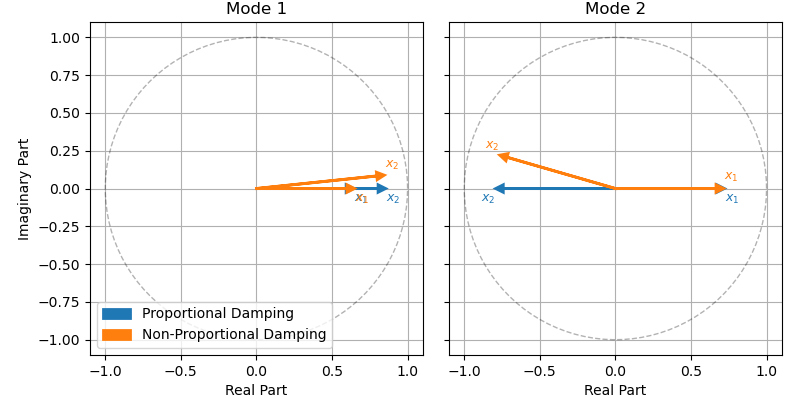

Complex Mode Shapes Details:

Mode 1:
  DOF 1: +0.599 -0.000j
           Magnitude: 0.599, Phase: -0.0°
  DOF 2: +0.796 +0.083j
           Magnitude: 0.801, Phase: 6.0°
  Phase difference (DOF2 - DOF1): 6.0°

Mode 2:
  DOF 1: +0.666 +0.000j
           Magnitude: 0.666, Phase: 0.0°
  DOF 2: -0.717 +0.207j
           Magnitude: 0.746, Phase: 163.9°
  Phase difference (DOF2 - DOF1): 163.9°


In [19]:
import matplotlib.pyplot as plt


# Enable interactive plots
%matplotlib widget

# Get default matlpotlib colors
COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]


def phase_normalize_mode_shapes(mode_shapes, reference_dof=0):
    """
    Phase-normalize complex mode shapes for consistent orientation and comparison.

    This function addresses the challenge of comparing complex mode shapes by:
    1. Using a reference DOF to establish a consistent phase reference
    2. Rotating each mode shape so the reference DOF lies on the positive real axis
    3. Preserving all relative phase relationships between DOFs

    Parameters:
    -----------
    mode_shapes : ndarray
        Complex mode shapes with shape (n_dofs, n_modes)
    reference_dof : int
        Index of the DOF to use as phase reference (default: 0, first DOF)

    Returns:
    --------
    phase_normalized_modes : ndarray
        Phase-normalized mode shapes with same shape as input

    Notes:
    ------
    After normalization:
    - The reference DOF will always point along the positive real axis
    - All relative phase differences are preserved
    - Magnitude relationships are unchanged
    """
    phase_normalized_modes = np.zeros_like(mode_shapes, dtype=complex)
    _, n_modes = mode_shapes.shape

    for mode_idx in range(n_modes):
        # Get the reference DOF value for this mode
        reference_value = mode_shapes[reference_dof, mode_idx]

        # Calculate the phase angle of the reference DOF
        reference_phase = np.angle(reference_value)

        # Create rotation factor to align reference DOF to positive real axis
        # This rotates the entire mode shape by -reference_phase
        rotation_factor = np.exp(-1j * reference_phase)

        # Apply rotation to all DOFs in this mode
        phase_normalized_modes[:, mode_idx] = mode_shapes[:, mode_idx] * rotation_factor

    # Return the phase-normalized mode shapes
    return phase_normalized_modes


def enforce_consistent_phase_difference(modes_a, modes_b):
    """
    Enforce consistent phase difference between two sets of mode shapes.

    This function ensures that the phase difference between corresponding DOFs
    in two sets of mode shapes has the same sign across all modes.

    Parameters:
    -----------
    modes_a : ndarray
        First set of mode shapes with shape (n_dofs, n_modes)
    modes_b : ndarray
        Second set of mode shapes with shape (n_dofs, n_modes)

    Returns:
    --------
    modes_b : ndarray
        Modified second set of mode shapes with consistent phase difference
    """
    # Calculate phase difference of x2 relative to x1 for each mode
    phase_diffs_a = np.angle(modes_a[1, :]) - np.angle(modes_a[0, :])
    phase_diffs_b = np.angle(modes_b[1, :]) - np.angle(modes_b[0, :])

    # Ensure second set has same phase difference sign as first set
    for mode_idx in range(modes_b.shape[1]):
        if np.sign(phase_diffs_a[mode_idx]) != np.sign(phase_diffs_b[mode_idx]):
            # If signs differ, flip mode shape of second set about the real axis (essentially take complex conjugate mode)
            modes_b[:, mode_idx] = np.conj(modes_b[:, mode_idx])

    # Return the modified second set of mode shapes
    return modes_b


def plot_mode_phase_diagram(
    modes_a,
    modes_b=None,
    modes_a_label="True Mode Shapes",
    modes_b_label="Estimated Mode Shapes",
):
    """
    Plot true vs estimated mode shapes

    Parameters:
    modes_a: array of shape (number of DOFs, number of modes) containing first set of mode shapes
    modes_b: array of shape (number of DOFs, number of modes) containing second set of mode shapes (optional)
    modes_a_label: label for the first set of mode shapes (default: "True Mode Shapes")
    modes_b_label: label for the second set of mode shapes (default: "Estimated Mode Shapes")
    """
    # Phase-normalize mode shapes for consistent comparison
    modes_a = phase_normalize_mode_shapes(modes_a)
    if modes_b is not None:
        modes_b = phase_normalize_mode_shapes(modes_b)
        modes_b = enforce_consistent_phase_difference(modes_a, modes_b)

    # Create a figure with a subplot for each mode
    n_modes = modes_a.shape[1]
    fig, axes = plt.subplots(1, n_modes, figsize=(4 * n_modes, 4), sharey=True)

    # Define angle to plot unit circle
    theta = np.linspace(0, 2 * np.pi, 100)

    # Iterate over each mode
    for i in range(n_modes):
        # Draw unit circle for reference
        axes[i].plot(np.cos(theta), np.sin(theta), "k--", alpha=0.3, linewidth=1)

        # Iterate over each degree of freedom
        for j in range(N_DOFS):
            # Plot vectror for true mode shape
            real_part = np.real(modes_a[j, i])
            imag_part = np.imag(modes_a[j, i])
            true_line = axes[i].arrow(
                0,
                0,
                real_part,
                imag_part,
                head_width=0.05,
                head_length=0.05,
                fc=COLORS[0],
                ec=COLORS[0],
                linewidth=2,
                zorder=2,
                label="True Mode Shape",
            )

            # Add text label to indicate degree of freedom
            text_x = real_part + .1 * np.sign(real_part) if real_part != 0 else .1
            text_y = imag_part + .07 * np.sign(imag_part) if imag_part != 0 else -.07
            axes[i].text(
                text_x,
                text_y,
                f"$x_{j+1}$",
                color=COLORS[0],
                fontsize=9,
                ha="center",
                va="center",
            )

            # Plot vector for estimated mode shape if provided
            if modes_b is not None:
                real_part = np.real(modes_b[j, i])
                imag_part = np.imag(modes_b[j, i])
                est_line = axes[i].arrow(
                    0,
                    0,
                    real_part,
                    imag_part,
                    head_width=0.05,
                    head_length=0.05,
                    fc=COLORS[1],
                    ec=COLORS[1],
                    linewidth=2,
                    zorder=3,
                    label="Estimated Mode Shape",
                )

                # Add text label to indicate degree of freedom
                text_x = real_part + .1 * np.sign(real_part) if real_part != 0 else .1
                text_y = imag_part + .07 * np.sign(imag_part) if imag_part != 0 else -.07
                axes[i].text(
                    text_x,
                    text_y,
                    f"$x_{j+1}$",
                    color=COLORS[1],
                    fontsize=9,
                    ha="center",
                    va="center",
                )

        # Add title, x-label, grid, and set aspect ratio
        axes[i].set_title(f"Mode {i+1}")
        axes[i].set_xlabel("Real Part")
        axes[i].grid(True)
        axes[i].set_aspect("equal")

    # Add legend if estimated modes are provided
    if modes_b is not None:
        axes[0].legend(
            [true_line, est_line],
            [modes_a_label, modes_b_label],
            loc="lower left",
        )

    # Add y-label to the first subplot
    axes[0].set_ylabel("Imaginary Part")

    # Set layout and show plot
    plt.tight_layout()
    plt.show()

    # Return the phase-normalized mode shapes for further analysis if needed
    return modes_a, modes_b


# Plot mode shapes comparison in phase diagram
phase_normalized_mode_shapes_proportional, phase_normalized_mode_shapes_non_proportional = plot_mode_phase_diagram(
    mode_shapes_proportional,
    mode_shapes_non_proportional,
    modes_a_label="Proportional Damping",
    modes_b_label="Non-Proportional Damping",
)

# Additional analysis
print("Complex Mode Shapes Details:")
print("=" * 50)
for mode_num in range(phase_normalized_mode_shapes_non_proportional.shape[1]):
    print(f"\nMode {mode_num+1}:")

    for dof in range(N_DOFS):
        magnitude = np.abs(phase_normalized_mode_shapes_non_proportional[dof, mode_num])
        phase = np.angle(phase_normalized_mode_shapes_non_proportional[dof, mode_num], deg=True)
        real_part = np.real(phase_normalized_mode_shapes_non_proportional[dof, mode_num])
        imag_part = np.imag(phase_normalized_mode_shapes_non_proportional[dof, mode_num])

        print(f"  DOF {dof+1}: {real_part:+.3f} {imag_part:+.3f}j")
        print(f"           Magnitude: {magnitude:.3f}, Phase: {phase:.1f}°")

    # Calculate phase difference between DOFs
    phase_diff = np.angle(
        phase_normalized_mode_shapes_non_proportional[1, mode_num], deg=True
    ) - np.angle(phase_normalized_mode_shapes_non_proportional[0, mode_num], deg=True)

    # Print phase difference
    print(f"  Phase difference (DOF2 - DOF1): {np.abs(phase_diff):.1f}°")

Let's create an animation of the mode shapes to show the difference between the proportional and non-proportional damping cases.

In [ ]:
import matplotlib.animation as animation
from matplotlib.patches import Rectangle, FancyBboxPatch, Circle
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import os


# Define animation parameters
fps = 30
duration = 2  # seconds for one complete cycle
n_frames = fps * duration


def draw_spring(ax, x1, y1, x2, y2, width=0.08, n_coils=10, color="k"):
    """Draw a spring between two points"""
    length = x2 - x1
    if abs(length) < 0.01:
        return

    # Create more realistic spring coordinates
    n_points = n_coils * 8
    t = np.linspace(0, 1, n_points)

    # Add small straight sections at the ends
    straight_fraction = 0.1
    spring_t = np.where(
        (t > straight_fraction) & (t < 1 - straight_fraction),
        (t - straight_fraction) / (1 - 2 * straight_fraction),
        np.where(t <= straight_fraction, 0, 1),
    )

    spring_x = x1 + t * length
    spring_y = y1 + width * np.sin(2 * np.pi * n_coils * spring_t) * np.where(
        (t > straight_fraction) & (t < 1 - straight_fraction), 1, 0
    )

    ax.plot(spring_x, spring_y, color=color, linewidth=2)


def draw_damper(ax, x1, y1, x2, y2, width=0.12, color="k"):
    """Draw a damper with fixed cylinder and moving piston"""
    total_length = abs(x2 - x1)
    if total_length < 0.01:
        return

    # Fixed cylinder dimensions
    cylinder_length = 0.4  # Fixed length
    cylinder_start = x1 + (total_length - cylinder_length) / 2

    # Draw cylinder (fixed)
    cylinder = Rectangle(
        (cylinder_start, y1 - width / 2),
        cylinder_length,
        width,
        facecolor="white",
        edgecolor=color,
        linewidth=2,
    )
    ax.add_patch(cylinder)

    # Draw end caps
    cap_width = width * 1.2
    left_cap = Rectangle(
        (cylinder_start - 0.02, y1 - cap_width / 2),
        0.04,
        cap_width,
        facecolor="gray",
        edgecolor=color,
        linewidth=1.5,
    )
    right_cap = Rectangle(
        (cylinder_start + cylinder_length - 0.02, y1 - cap_width / 2),
        0.04,
        cap_width,
        facecolor="gray",
        edgecolor=color,
        linewidth=1.5,
    )
    ax.add_patch(left_cap)
    ax.add_patch(right_cap)

    # Draw piston rod (moving)
    piston_pos = x1 + (x2 - x1) * 0.5  # Piston position
    ax.plot([x1, piston_pos - 0.02], [y1, y1], color=color, linewidth=4)
    ax.plot([piston_pos + 0.02, x2], [y1, y1], color=color, linewidth=4)

    # Draw piston head inside cylinder
    if cylinder_start < piston_pos < cylinder_start + cylinder_length:
        piston_head = Rectangle(
            (piston_pos - 0.02, y1 - width / 2 * 0.8),
            0.04,
            width * 0.8,
            facecolor="darkgray",
            edgecolor=color,
            linewidth=1.5,
        )
        ax.add_patch(piston_head)


def create_mode_comparison_animation(
    mode_idx,
    mode_shapes_prop,
    mode_shapes_non_prop,
    natural_freqs_prop,
    natural_freqs_non_prop,
    damping_ratios_prop,
    damping_ratios_non_prop,
    filename,
):
    """
    Create animation comparing proportional and non-proportional damping for a specific mode.
    Phase-normalized mode shapes should be provided for the non-proportional case for consistent comparison.

    Parameters:
    -----------
    mode_idx : int
        Index of the mode to animate (0 for first mode, 1 for second mode, etc.)
    mode_shapes_prop : ndarray
        Mode shapes for the proportionally damped system with shape (n_dofs, n_modes)
    mode_shapes_non_prop : ndarray
        Mode shapes for the non-proportionally damped system with shape (n_dofs, n_modes)
    natural_freqs_prop : ndarray
        Natural frequencies for the proportionally damped system with shape (n_modes,)
    natural_freqs_non_prop : ndarray
        Natural frequencies for the non-proportionally damped system with shape (n_modes,)
    damping_ratios_prop : ndarray
        Damping ratios for the proportionally damped system with shape (n_modes,)
    damping_ratios_non_prop : ndarray
        Damping ratios for the non-proportionally damped system with shape (n_modes,)
    filename : str
        Path to save the animation as a GIF file

    Returns:
    --------
    anim : FuncAnimation
        The created animation object
    """

    # Create figure
    fig, (ax_prop, ax_non_prop) = plt.subplots(2, 1, figsize=(12, 8))

    # Set up axes
    for ax in [ax_prop, ax_non_prop]:
        ax.set_xlim(-1, 5)
        ax.set_ylim(-0.8, 0.8)
        ax.set_aspect("equal")
        ax.axis("off")

    # Animation parameters
    equilibrium_positions = np.array([1.5, 3.5])
    mass_width = 0.5
    mass_height = 0.4
    amplitude = 0.6

    # Calculate phase information for proportional damping
    # Phase is zero if DOFs have same sign, otherwise phase is 180 degrees
    phase_diff_prop = (
        0 if mode_shapes_prop[0, mode_idx] * mode_shapes_prop[1, mode_idx] >= 0 else 180
    )

    # Calculate phase information for non-proportional damping
    phases_non_prop = np.angle(mode_shapes_non_prop[:, mode_idx], deg=True)
    phase_diff_non_prop = (phases_non_prop[1] - phases_non_prop[0])

    # Create phase vector for animation
    phase_non_prop_animation = np.array([0, np.deg2rad(phase_diff_non_prop)])

    def init():
        return []

    def animate(frame):
        # Clear axes
        ax_prop.clear()
        ax_non_prop.clear()

        # Set axis properties
        for ax in [ax_prop, ax_non_prop]:
            ax.set_xlim(-1, 5)
            ax.set_ylim(-0.8, 0.8)
            ax.set_aspect("equal")
            ax.axis("off")

        # Calculate phase for exactly one cycle
        phase = 2 * np.pi * frame / n_frames

        # Proportional damping displacements (both DOFs in phase)
        displacements_prop = amplitude * mode_shapes_prop[:, mode_idx] * np.cos(phase)

        # Non-proportional damping displacements (with phase lag)
        displacements_non_prop = (
            amplitude
            * np.abs(mode_shapes_non_prop[:, mode_idx])
            * np.cos(phase + phase_non_prop_animation)
        )

        # Draw both systems
        for ax, displacements, damping_type, nat_freq, damp_ratio, phase_diff in [
            (
                ax_prop,
                displacements_prop,
                "Proportional",
                natural_freqs_prop[mode_idx],
                damping_ratios_prop[mode_idx],
                phase_diff_prop,
            ),
            (
                ax_non_prop,
                displacements_non_prop,
                "Non-Proportional",
                natural_freqs_non_prop[mode_idx],
                damping_ratios_non_prop[mode_idx],
                phase_diff_non_prop,
            ),
        ]:

            # Add subtitle
            title = f"{damping_type} Damping: f = {nat_freq/(2*np.pi):.1f} Hz, ζ = {damp_ratio:.3f}, Phase diff = {phase_diff:.1f}°"
            ax.text(2, 0.65, title, ha="center", fontsize=12)

            # Current positions
            positions = equilibrium_positions + displacements

            # Draw wall
            wall_x = -0.5
            wall_thickness = 0.08
            wall_rect = Rectangle(
                (wall_x - wall_thickness, -0.6), wall_thickness, 1.2, facecolor="black"
            )
            ax.add_patch(wall_rect)

            # Draw hatching on wall
            for i in range(8):
                y_pos = -0.5 + i * 0.15
                ax.plot(
                    [wall_x - wall_thickness - 0.05, wall_x - wall_thickness],
                    [y_pos - 0.05, y_pos + 0.05],
                    "k-",
                    linewidth=1.5,
                )

            # Draw springs (top row)
            draw_spring(ax, wall_x, 0.2, positions[0] - mass_width / 2, 0.2)
            draw_spring(
                ax,
                positions[0] + mass_width / 2,
                0.2,
                positions[1] - mass_width / 2,
                0.2,
            )

            # Draw dampers (bottom row)
            draw_damper(ax, wall_x, -0.2, positions[0] - mass_width / 2, -0.2)
            draw_damper(
                ax,
                positions[0] + mass_width / 2,
                -0.2,
                positions[1] - mass_width / 2,
                -0.2,
            )

            # Draw masses
            for i, pos in enumerate(positions):
                mass = FancyBboxPatch(
                    (pos - mass_width / 2, -mass_height / 2),
                    mass_width,
                    mass_height,
                    boxstyle="round,pad=0.02",
                    facecolor="lightgray",
                    edgecolor="black",
                    linewidth=2,
                )
                ax.add_patch(mass)

                # Add mass label
                ax.text(
                    pos,
                    0,
                    f"$m_{i+1}$",
                    ha="center",
                    va="center",
                    fontsize=14,
                    fontweight="bold",
                )

            # Draw reference lines for equilibrium positions
            for i, eq_pos in enumerate(equilibrium_positions):
                ax.axvline(
                    x=eq_pos,
                    ymin=0.1,
                    ymax=0.15,
                    color="gray",
                    linestyle="--",
                    alpha=0.5,
                )

            # Add displacement arrows
            arrow_y = -0.55
            for i, (pos, eq_pos) in enumerate(zip(positions, equilibrium_positions)):
                if abs(pos - eq_pos) > 0.02:
                    color = "red" if i == 0 else "blue"
                    ax.annotate(
                        "",
                        xy=(pos, arrow_y),
                        xytext=(eq_pos, arrow_y),
                        arrowprops=dict(arrowstyle="<->", color=color, lw=2),
                    )
                    ax.text(
                        (pos + eq_pos) / 2,
                        arrow_y - 0.08,
                        f"$x_{i+1}$",
                        ha="center",
                        va="top",
                        color=color,
                        fontsize=10,
                    )

        return []

    # Create animation
    anim = animation.FuncAnimation(
        fig,
        animate,
        init_func=init,
        frames=n_frames,
        interval=1000 / fps,
        blit=True,
        repeat=True,
    )

    # Save as GIF
    print(f"Saving animation: {filename}")
    anim.save(filename, writer="pillow", fps=fps, dpi=120)
    plt.close(fig)

    # Return the animation object
    return anim


# Create animations for both modes
print("Creating Mode 1 comparison animation...")
create_mode_comparison_animation(
    0,
    mode_shapes_proportional,
    phase_normalized_mode_shapes_non_proportional,
    natural_frequencies_proportional,
    natural_frequencies_non_proportional,
    damping_ratios_proportional,
    damping_ratios_non_proportional,
    os.path.join("resources", "mode1_comparison.gif"),
)

print("Creating Mode 2 comparison animation...")
create_mode_comparison_animation(
    1,
    mode_shapes_proportional,
    phase_normalized_mode_shapes_non_proportional,
    natural_frequencies_proportional,
    natural_frequencies_non_proportional,
    damping_ratios_proportional,
    damping_ratios_non_proportional,
    os.path.join("resources", "mode2_comparison.gif"),
)

print("\nAnimations saved successfully!")
print("Files created:")
print("- mode1_comparison.gif")
print("- mode2_comparison.gif")

Creating Mode 1 comparison animation...
Saving animation: resources\mode1_comparison.gif
Creating Mode 2 comparison animation...
Saving animation: resources\mode2_comparison.gif

Animations saved successfully!
Files created:
- mode1_comparison.gif
- mode2_comparison.gif


Let's look at the animation of the first mode:

![SegmentLocal](resources/mode1_comparison.gif "segment")

and at that of the second mode:

![SegmentLocal](resources/mode2_comparison.gif "segment")

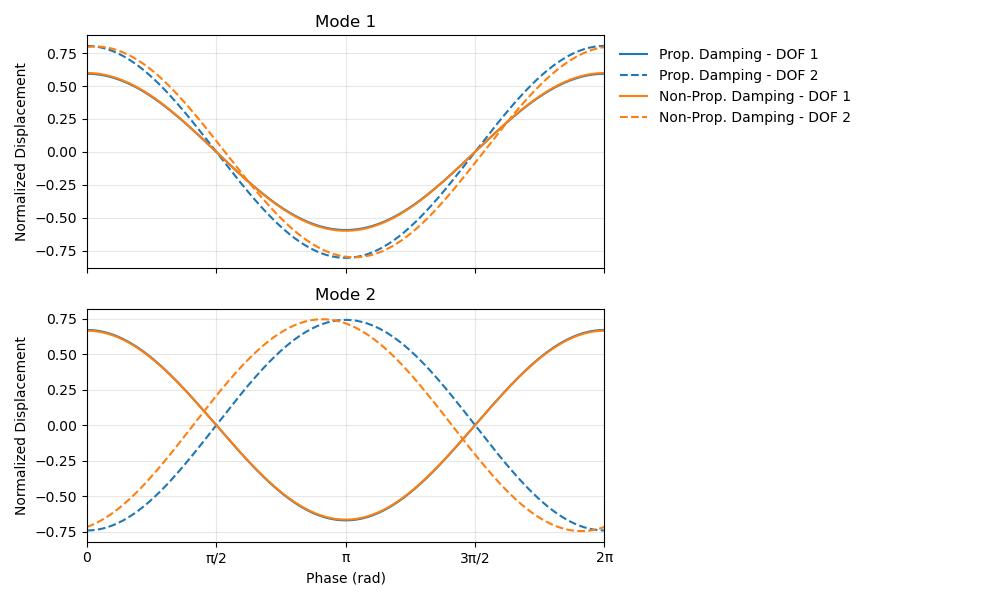

In [5]:
# Create a static figure showing the phase relationships
n_modes = mode_shapes_proportional.shape[1]
fig, (ax1, ax2) = plt.subplots(n_modes, 1, figsize=(10, 3 * n_modes), sharex=True)

# Time array for one complete cycle
t = np.linspace(0, 2 * np.pi, 200)

# Loop through each mode and plot the displacement cycle for each degree of freedom
for ax, mode_idx in zip([ax1, ax2], [0, 1]):

    # Get mode shape information
    mode_prop = mode_shapes_proportional[:, mode_idx]
    mode_non_prop = mode_shapes_non_proportional[:, mode_idx]
    phases = np.angle(mode_non_prop)

    # Plot proportional damping (both DOFs in phase)
    ax.plot(
        t, mode_prop[0] * np.cos(t), "-", color=COLORS[0], label="Prop. Damping - DOF 1"
    )
    ax.plot(
        t,
        mode_prop[1] * np.cos(t),
        "--",
        color=COLORS[0],
        label="Prop. Damping - DOF 2",
    )

    # Plot non-proportional damping (with phase lag)
    ax.plot(
        t,
        np.abs(mode_non_prop[0]) * np.cos(t),
        "-",
        color=COLORS[1],
        label="Non-Prop. Damping - DOF 1",
    )
    ax.plot(
        t,
        np.abs(mode_non_prop[1]) * np.cos(t + phases[1] - phases[0]),
        "--",
        color=COLORS[1],
        label="Non-Prop. Damping - DOF 2",
    )

    ax.set_ylabel("Normalized Displacement")
    ax.set_title(f"Mode {mode_idx + 1}")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 2 * np.pi)
    ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    ax.set_xticklabels(["0", "π/2", "π", "3π/2", "2π"])

# Add x-label to the last subplot
ax2.set_xlabel("Phase (rad)")

# Add legend to first subplot
ax1.legend(loc="upper right", bbox_to_anchor=(1.5, 1), frameon=False)

plt.tight_layout()
plt.show()

## Parameter Estimation from Random Excitation <a id='estimation-random'></a>

***

### Data Generation and Processing <a id='data-generation-processing'></a>

In [6]:
from scipy import signal


def two_dof_mass_spring_damper(state, t, force):
    """
    Define system dynamics: dq/dt = f(q, t)

    Parameters:
    state (array): [displacement 1, displacement 2, velocity 1, velocity 2]
    t (float): Time
    force (function): External force signal, inputted as a function

    Returns:
    array: State derivatives [velocity 1, velocity 2, acceleration 1, acceleration 2]
    """

    # Unpack state variables
    x1, x2, x1dot, x2dot = state

    # Calculate accelerations based on the equation of motion
    x1ddot = (
        -(
            K[0, 0] * x1
            + K[0, 1] * x2
            + C_non_proportional[0, 0] * x1dot
            + C_non_proportional[0, 1] * x2dot
        )
        / M[0, 0]
    )
    x2ddot = (
        force(t)
        - (
            K[1, 0] * x1
            + K[1, 1] * x2
            + C_non_proportional[1, 0] * x1dot
            + C_non_proportional[1, 1] * x2dot
        )
        / M[1, 1]
    )

    # Return state derivatives
    return [x1dot, x2dot, x1ddot, x2ddot]


def calculate_h1_frf(
    input_signal, output_signal_array, fs, window="hann", nperseg=None, noverlap=None
):
    """
    Calculate the Frequency Response Function (FRF) with the H1 estimator and using SciPy's implementation of Welch's method.

    This function computes the H1 estimator: H1(f) = Gxy(f)/Gxx(f), where:
    - Gxy(f) is the cross-spectral density between input and output
    - Gxx(f) is the power spectral density of the input

    Parameters:
    -----------
    input_signal : array_like
        Input force signal
    output_signal_array : ndarray
        Array of output displacement signals with shape (n_outputs, n_samples)
    fs : float
        Sampling frequency of the signals
    window : str or tuple or array_like
        Window specification for the spectral estimation (default: 'hann')
    nperseg : int, optional
        Length of each segment (default: min(N, 256) where N is signal length)
    noverlap : int, optional
        Number of points to overlap between segments (default: nperseg//2)

    Returns:
    --------
    freqs : ndarray
        Array of sample frequencies
    frf : ndarray
        Array of FRFs for each output signal with shape (n_outputs, n_frequencies)
    """
    # Find number of output responses and initialize list of FRFs
    n_outputs = output_signal_array.shape[0]
    frfs = []

    # Process each output channel
    for i in range(n_outputs):
        # Calculate cross-spectral density between input and output
        # This gives us Gxy(f)
        f, Gxy = signal.csd(
            input_signal,
            output_signal_array[i],
            fs=fs,
            window=window,
            nperseg=nperseg,
            noverlap=noverlap,
            detrend="constant",
            return_onesided=False,
        )

        # Calculate power spectral density of the input
        # This gives us Gxx(f)
        _, Gxx = signal.welch(
            input_signal,
            fs=fs,
            window=window,
            nperseg=nperseg,
            noverlap=noverlap,
            detrend="constant",
            return_onesided=False,
        )

        # Calculate H1 estimator: H1(f) = Gxy(f)/Gxx(f)
        frf_channel = Gxy / Gxx
        frfs.append(frf_channel)

    # Return the frequencies and FRFs
    return f, np.array(frfs)


def plot_spectrum(
    frequencies, spectrum, unwrap=False, axes=None, label=None, title=None
):
    """Plot magnitude and phase spectrum of a signal

    Parameters:
    frequencies (array): Frequency vector of full spectrum (positive and negative frequencies)
    spectrum (array): Complex spectrum values
    unwrap (bool): Unwrap phase if True (optional)
    axes (array): Axes to plot on (optional)
    label (str): Label for the plot (optional)
    title (str): Plot title (optional)
    """
    # Get positive frequencies only (since spectrum is symmetric for real signals)
    pos_mask = frequencies >= 0
    pos_freqs = frequencies[pos_mask]
    pos_spectrum = spectrum[pos_mask]

    # Calculate magnitude in dB and phase in radians
    magnitude_db = 20 * np.log10(np.abs(pos_spectrum))
    phase = np.angle(pos_spectrum)

    # Unwrap phase if specified
    if unwrap:
        phase = np.unwrap(phase)

    # Convert phase to degrees
    phase = np.rad2deg(phase)

    # Create figure with two subplots if axes are not provided
    if axes is None:
        fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    else:
        fig = axes[0].figure

    # Plot magnitude
    axes[0].plot(pos_freqs, magnitude_db, label=label)
    axes[0].set_ylabel("Magnitude")
    axes[0].grid(True)

    # Plot phase
    axes[1].plot(pos_freqs, phase)
    axes[1].set_ylabel("Phase, deg")
    axes[1].set_xlabel("Frequency, Hz")
    axes[1].grid(True)

    # Set title if provided
    if title:
        axes[0].set_title(f"{title} Magnitude Spectrum")
        axes[1].set_title(f"{title} Phase Spectrum")

    # Return figure and axes for further customization if needed
    return fig, axes

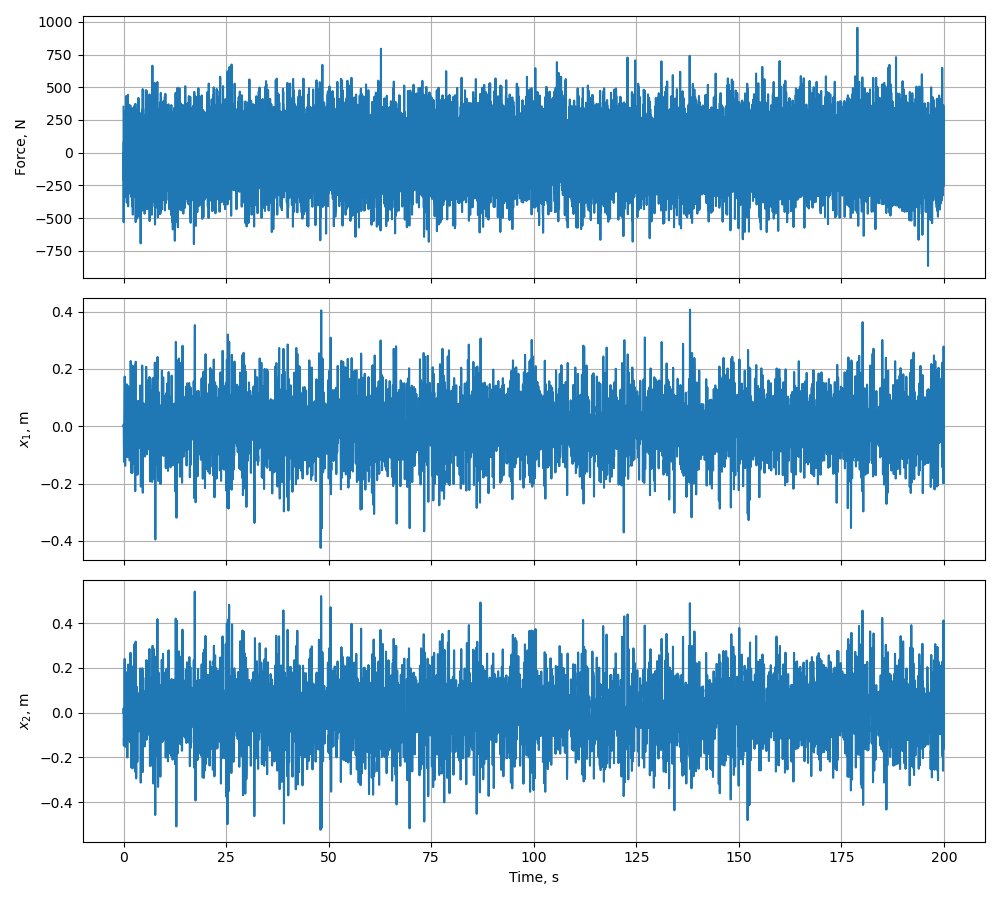

In [7]:
from scipy.interpolate import interp1d  # import interp1d function for interpolation
from scipy.integrate import odeint  # import odeint function for solving ODEs


# Create time array
t_span = 200  # [s]
f_sampling = 100  # sampling frequency [Hz]
t_vector = np.arange(0, t_span, 1 / f_sampling)  # time vector [s]

# Generate random force signal
np.random.seed(11)  # set random seed for reproducibility
force_rms = 200  # RMS of the force signal [N]
random_signal = np.random.normal(
    size=len(t_vector)
)  # random signal with normal distribution centered at 0
random_force_signal = random_signal * (
    force_rms / np.sqrt(np.mean(random_signal**2))
)  # scale random signal to desired RMS [N]

# Create interpolated force function
random_force_function = interp1d(
    t_vector, random_force_signal, bounds_error=False, fill_value=0
)

# Solve ODE
initial_state = [0, 0, 0, 0]  # zero-displacement and zero-velocity initial conditions
solution = odeint(
    two_dof_mass_spring_damper, initial_state, t_vector, args=(random_force_function,)
)

# Extract displacements at the two degrees of freedom
displacements = solution[:, :2].T

# Create figure with three subplots
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 9))

# Plot force
random_force_signal = random_force_function(t_vector)
axes[0].plot(t_vector, random_force_signal)
axes[0].set_ylabel("Force, N")
axes[0].grid(True)

# Plot displacement
axes[1].plot(t_vector, displacements[0])
axes[1].set_ylabel("$x_1$, m")
axes[1].grid(True)

# Plot velocity
axes[2].plot(t_vector, displacements[1])
axes[2].set_ylabel("$x_2$, m")
axes[2].grid(True)
axes[2].set_xlabel("Time, s")

# Set layout and show plot
plt.tight_layout()
plt.show()

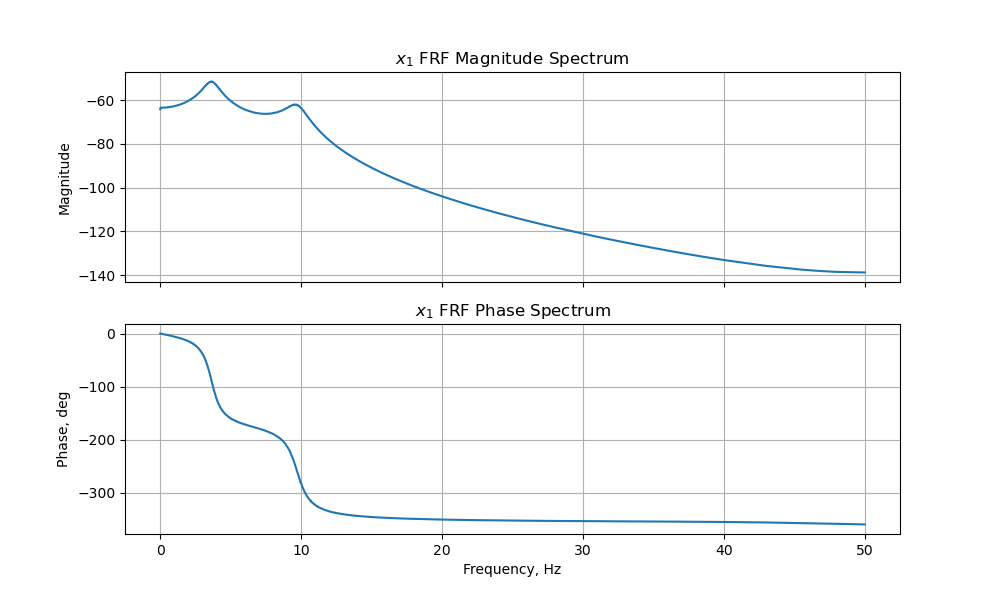

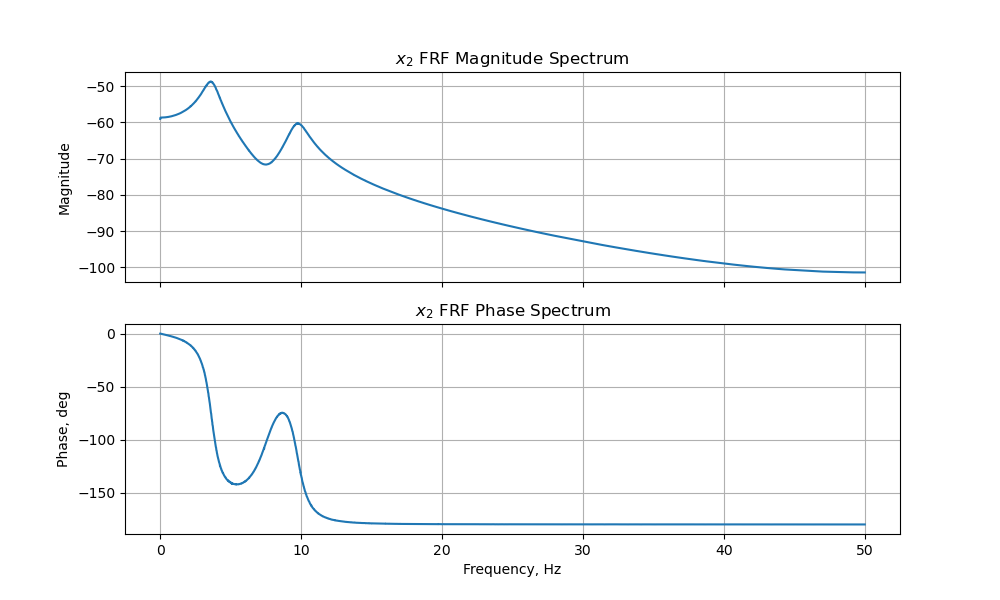

In [8]:
# Calculate improved FRF
frequencies, measured_frfs = calculate_h1_frf(
    random_force_signal, displacements, f_sampling, nperseg=7500
)

# Plot FRF spectrum for each degree of freedom
_, _ = plot_spectrum(frequencies, measured_frfs[0], unwrap=True, title="$x_1$ FRF")
plt.show()
_, _ = plot_spectrum(frequencies, measured_frfs[1], unwrap=True, title="$x_2$ FRF")
plt.show()

### Parameter Estimation with Fixed Model Order <a id='parameter-estimation-fixed'></a>

In [9]:
def generate_orthogonal_polynomials(omegas, order, weights):
    """
    Generate orthogonal polynomials using the Forsythe method and build the conversion matrix
    to map from orthogonal polynomial coefficients to ordinary polynomial coefficients.

    Parameters:
    omegas (array): Frequency points (real-valued)
    order (int): Maximum order of polynomials to generate
    weights (array): Weighting function values at each frequency point

    Returns:
    tuple: (
        complex_F: Complex orthogonal polynomials with shape (len(omegas), order+1),
        Gamma: Conversion matrix with shape (order+1, order+1) that maps from orthogonal
           to ordinary polynomial coefficients
    )
    """
    # Find number of frequency points
    n_frequencies = len(omegas)

    # Initialize array to store polynomials
    complex_F = np.zeros((n_frequencies, order + 1), dtype=complex)
    F = np.zeros((n_frequencies, order + 1), dtype=float)
    G = np.zeros((n_frequencies, order + 1), dtype=float)
    V = np.zeros(order + 1, dtype=float)

    # Initialize conversion matrix Gamma
    # Gamma[k,j] = coefficient of s^j in the k-th orthogonal polynomial
    Gamma = np.zeros((order + 1, order + 1))

    # coeff_arrays is a list of arrays, where each array represents one orthogonal polynomial in terms of powers of s
    # coeff_arrays[k] contains the coefficients of the k-th orthogonal polynomial φₖ(s)
    # coeff_arrays[k][j] holds the coefficient of s^j in the expansion of φₖ(s)
    coeff_arrays = [np.zeros(order + 1) for _ in range(order + 1)]

    # Calculate polynomials for k=0
    p0 = 1.0 / np.sqrt(np.sum(weights))  # coefficient for φ₀(s)
    F[:, 0] = p0  # for k=0 the orthogonal polynomial is constant
    complex_F[:, 0] = F[:, 0] * (1j**0)

    # Assign value of the coefficient of s^0 in φ₀(s)
    coeff_arrays[0][0] = p0
    Gamma[0, 0] = p0

    # Calculate polynomials for k=1
    G[:, 1] = omegas * F[:, 0]  # F[:,-1]=0, V[0]=0
    norm_factor = np.sqrt(np.sum(G[:, 1] ** 2 * weights))
    F[:, 1] = G[:, 1] / norm_factor
    complex_F[:, 1] = F[:, 1] * (1j**1)

    # For k=1, the orthogonal polynomial is p1*s
    p1 = p0 / norm_factor
    coeff_arrays[1][1] = p1  # coefficient of s^1 in φ₁(s)
    Gamma[1, 1] = p1

    # Iterate from k=2 to k=order
    for k in range(2, order + 1):
        # Calculate V[k-1]
        V[k - 1] = np.sum(omegas * F[:, k - 1] * F[:, k - 2] * weights)

        # Calculate G[:, k]
        G[:, k] = omegas * F[:, k - 1] - V[k - 1] * F[:, k - 2]

        # Calculate norm_factor
        norm_factor = np.sqrt(np.sum(G[:, k] ** 2 * weights))

        # Calculate F[:, k]
        F[:, k] = G[:, k] / norm_factor

        # Calculate complex polynomials
        complex_F[:, k] = F[:, k] * (1j**k)

        # Update coefficient arrays for this orthogonal polynomial
        # φₖ(s) = (s*φₖ₋₁(s) - V[k-1]*φₖ₋₂(s)) / norm_factor

        # First part: s*φₖ₋₁(s) -> shift coefficients up by one power of s
        temp_coeffs = np.zeros(
            order + 1
        )  # holds intermediate calculation before normalization
        for i in range(order):
            temp_coeffs[i + 1] = coeff_arrays[k - 1][i]

        # Second part: subtract V[k-1]*φₖ₋₂(s)
        for i in range(order + 1):
            temp_coeffs[i] -= V[k - 1] * coeff_arrays[k - 2][i]

        # Normalize
        coeff_arrays[k] = temp_coeffs / norm_factor

        # Update conversion matrix Gamma with these coefficients
        Gamma[k, :] = coeff_arrays[k]

    # Return the complex orthogonal polynomials and the conversion matrix
    return complex_F, Gamma


def grfp_curve_fit(frequencies, frfs, numerator_order, denominator_order):
    """
    Implements the Global Rational Fraction Polynomial (GRFP) method for curve fitting
    multiple FRF measurements simultaneously.

    Parameters:
    ----------
    frequencies : ndarray
        Array of frequency points (should be a set of symmetric frequencies around zero)
    frfs : ndarray
        Array of FRF measurements with shape (n_dofs, n_frequencies)
    numerator_order : int
        Order of the numerator polynomial
    denominator_order : int
        Order of the denominator polynomial

    Returns:
    -------
    tuple
        - a_coeffs: List of numerator ordinary polynomial coefficients for each DOF
        - b_coeffs: Denominator ordinary polynomial coefficients
    """
    # Find number of response FRFs and frequency points
    n_dofs = frfs.shape[0]
    n_freqs = frequencies.shape[0]

    # Create weights for polynomials
    # For numerator: uniform weighting
    numerator_weights = np.ones_like(frequencies)

    # For denominator: sum of squared magnitudes of all FRFs
    denominator_weights = np.sum(np.abs(frfs) ** 2, axis=0)

    # Generate numerator orthogonal polynomials
    phi, Gamma_numerator = generate_orthogonal_polynomials(
        frequencies, numerator_order, numerator_weights
    )

    # Generate denominator orthogonal polynomials
    theta, Gamma_denominator = generate_orthogonal_polynomials(
        frequencies, denominator_order, denominator_weights
    )

    # Setup matrices for the squared-error minimization problem
    D_T_list = []  # D_T,j matrices
    X_list = []  # X_j matrices
    H_list = []  # H_j vectors

    # Loop through each degree of freedom
    for j in range(n_dofs):
        # Calculate T_j matrix
        T_j = (
            theta[:, :-1] * frfs[j][:, np.newaxis]
        )  # Broadcasting to create T_j matrix

        # Calculate D_T,j matrix
        D_T_j = np.diag(
            np.sum(np.abs(T_j) ** 2, axis=0)
        )  # Diagonal matrix of sum of squares along frequency points
        D_T_list.append(D_T_j)

        # Calculate X_j matrix
        X_j = -np.real(phi.conj().T @ T_j)
        X_list.append(X_j)

        # Calculate W_j vector
        W_j = frfs[j] * theta[:, -1]

        # Calculate H_j vector
        H_j = np.real(phi.conj().T @ W_j)
        H_list.append(H_j)

    # Calculate left and right-hand sides of the linear system for the denominator coefficients
    LHS = np.sum([D_Tj for D_Tj in D_T_list], axis=0) - np.sum(
        [X_j.T @ X_j for X_j in X_list], axis=0
    )
    RHS = -np.sum([X_j.T @ H_j for X_j, H_j in zip(X_list, H_list)], axis=0)

    # Solve for denominator coefficients d
    D = np.linalg.solve(LHS, RHS)

    # Add the last coefficient (d_n = 1)
    d_coeffs = np.append(D, 1)

    # Convert orthogonal denominator coefficients to ordinary denominator coefficients
    b_coeffs = np.zeros(denominator_order + 1, dtype=complex)
    for i in range(denominator_order + 1):
        b_coeffs[i] = np.sum(
            d_coeffs[i:]
            * Gamma_denominator[i:, i]
            * 1j ** (np.arange(denominator_order + 1 - i))
        )

    # Calculate numerator coefficients c_j for each DOF and convert to ordinary coefficients
    # Initialize lists for coefficients
    a_coeffs_list = []
    c_coeffs_list = []

    # Loop through each degree of freedom
    for j in range(n_dofs):
        # Find orthogonal coefficients
        C_j = H_list[j] - X_list[j] @ D
        c_coeffs_list.append(C_j)

        # Convert orthogonal coefficients to ordinary coefficients
        a_coeffs_list.append(np.zeros(numerator_order + 1, dtype=complex))
        for i in range(numerator_order + 1):
            a_coeffs_list[j][i] = np.sum(
                c_coeffs_list[j][i:]
                * Gamma_numerator[i:, i]
                * 1j ** (np.arange(numerator_order + 1 - i))
            )

    # Return the coefficients and conversion matrices
    return a_coeffs_list, b_coeffs, c_coeffs_list, d_coeffs, phi, theta


def calculate_fitted_frf(angular_frequencies, a_coeffs_list, b_coeffs):
    """
    Calculate the fitted FRF using the polynomial coefficients.

    Parameters:
    ----------
    angular_frequencies : ndarray
        Array of angular frequencies (rad/s)
    a_coeffs_list : list
        List of numerator polynomial coefficients for each DOF
    b_coeffs : ndarray
        Denominator polynomial coefficients

    Returns:
    -------
    fitted_frf : ndarray
        Fitted FRF for each DOF
    """
    # Initialize arrray to store fitted FRFs
    fitted_frfs = np.zeros(
        (len(a_coeffs_list), len(angular_frequencies)), dtype=complex
    )

    # Loop through each degree of freedom to compare measured and fitted FRFs
    for j in range(N_DOFS):
        # Calculate fitted FRF using the polynomial coefficients
        num = np.polyval(a_coeffs_list[j][::-1], 1j * angular_frequencies)
        den = np.polyval(b_coeffs[::-1], 1j * angular_frequencies)
        fitted_frfs[j] = num / den

    # Return the fitted FRFs
    return fitted_frfs


def extract_poles(b_coeffs):
    """
    Extract poles from the denominator polynomial coefficients.

    Parameters:
    ----------
    b_coeffs : ndarray
        Denominator ordinary polynomial coefficients

    Returns:
    -------
    tuple:
        - natural_freqs: array of natural frequencies (rad/s) of size (n_modes,)
        - damping_ratios: array of damping ratios of size (n_modes,)
        - pole_pairs: array of complex conjugate pole pairs of size (n_modes, 2)
    """
    # Find roots of the denominator polynomial
    lambdas = np.roots(b_coeffs[::-1])

    # Initialize array of pole pairs, natural frequencies, and damping ratios
    n_modes = len(lambdas) // 2
    pole_pairs = np.zeros((n_modes, 2), dtype=complex)
    natural_freqs = np.zeros(n_modes, dtype=float)
    damping_ratios = np.zeros(n_modes, dtype=float)

    # Process poles to find complex conjugate pairs
    remaining_poles = lambdas.copy()
    i = 0
    while len(remaining_poles) > 0:
        # Take the first pole as the reference pole
        p = remaining_poles[0]

        # Calculate square root distance to other poles
        distances = np.sqrt(
            (remaining_poles[1:].real - p.real) ** 2
            + (remaining_poles[1:].imag + p.imag) ** 2
        )

        # Find the closest pole
        closest_idx = np.argmin(distances) + 1
        closest_pole = remaining_poles[closest_idx]

        # Store the pole pair
        pole_pairs[i] = np.array([p, closest_pole])

        # Calculate natural frequency
        natural_freqs[i] = np.abs(p)

        # Calculate damping ratio
        damping_ratios[i] = -p.real / natural_freqs[i]

        # Remove the processed poles from the list and update the index
        remaining_poles = np.delete(remaining_poles, [0, closest_idx])
        i += 1

    # Sort arrays by natural frequency (ascending)
    sort_indices = np.argsort(natural_freqs)
    pole_pairs = pole_pairs[sort_indices]
    natural_freqs = natural_freqs[sort_indices]
    damping_ratios = damping_ratios[sort_indices]

    # Return results
    return natural_freqs, damping_ratios, pole_pairs


def calculate_modes(a_coeffs_list, pole_pairs, drive_index=1):
    """
    Calculate mode shapes from the numerator coefficients and poles.

    Parameters:
    ----------
    a_coeffs_list : list
        List of numerator ordinary polynomial coefficients for each DOF
    pole_pairs : ndarray
        Array of complex conjugate pole pairs of size (n_modes, 2)
    drive_index : int
        Index of the driving point (default: 1 for second DOF)

    Returns:
    -------
    tuple:
        - residues: Residues for each DOF and mode
        - modes: Mode shapes (normalized)
    """
    # Find number of degrees of freedom and modes
    n_dofs = len(a_coeffs_list)
    n_modes = pole_pairs.shape[0]

    # Find numerator polynomial order
    numerator_order = len(a_coeffs_list[0]) - 1

    # Initialize arrays for residues and mode shapes
    residues = np.zeros((n_dofs, n_modes), dtype=complex)
    modes = np.zeros((n_dofs, n_modes), dtype=complex)

    # Loop through each degree of freedom
    for j in range(n_dofs):
        # Calculate residues for each mode
        for i in range(n_modes):
            poles = pole_pairs[i]
            remaining_poles = np.delete(pole_pairs, i, axis=0)
            residues[j, i] = np.sum(
                a_coeffs_list[j] * poles[0] ** np.arange(numerator_order + 1)
            ) / (
                (poles[0] - poles[1])
                * np.prod(
                    (poles[0] - remaining_poles[:, 0])
                    * (poles[0] - remaining_poles[:, 1])
                )
            )

    # Use the driving point residues to normalize mode shapes
    # Scale factor is square root of driving point residues
    # v_jr = R_jr / sqrt(R_2r)
    scale_factors = np.sqrt(residues[drive_index, :])

    # Iterate over each degree of freedom
    for j in range(n_dofs):
        # Mode shape component is equal to the ratio of residue to scale factors
        modes[j, :] = residues[j, :] / scale_factors

    # Normalize mode shapes to unit length
    norms = np.linalg.norm(modes, axis=0)
    modes /= norms

    # Return the mode shapes
    return modes

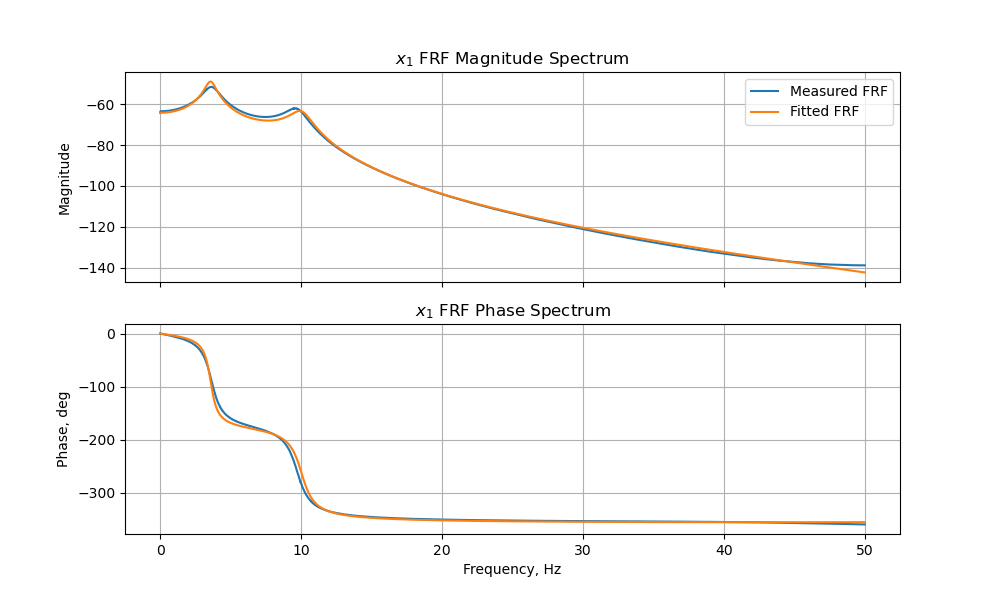

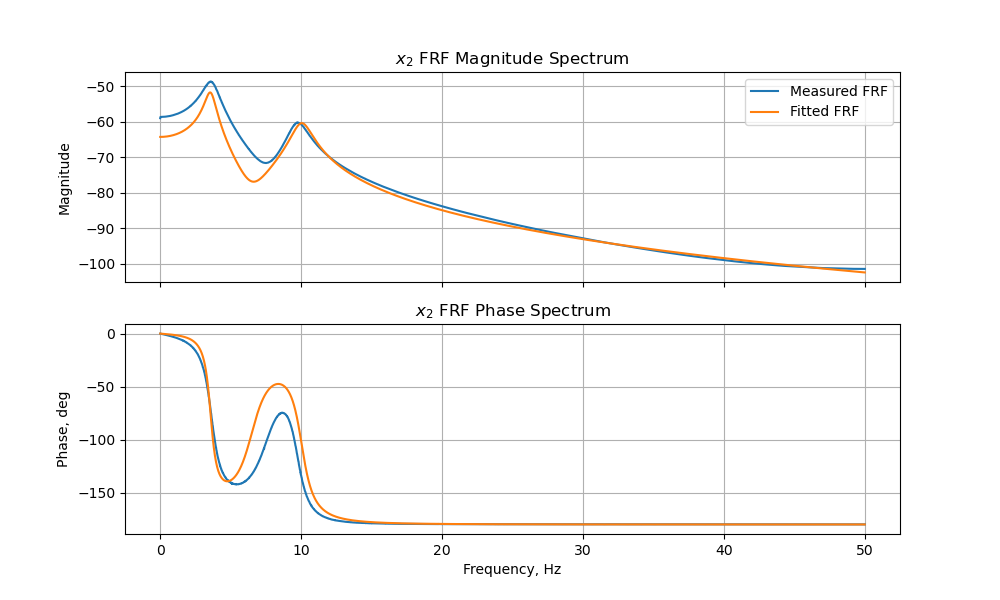

In [10]:
# Select numerator and denominator orders
numerator_order = 2
denominator_order = 4

# Take symmetric frequency points around zero (exclude Nyquist frequency point)
symmetric_mask = np.abs(frequencies) < f_sampling / 2
symmetric_angular_frequencies = 2 * np.pi * frequencies[symmetric_mask]

# Perform global curve fitting
a_coeffs_list, b_coeffs, _, _, _, _ = grfp_curve_fit(
    symmetric_angular_frequencies,
    measured_frfs[:, symmetric_mask],
    numerator_order,
    denominator_order,
)

# Calculate fitted FRFs
angular_frequencies = 2 * np.pi * frequencies
fitted_frfs = calculate_fitted_frf(angular_frequencies, a_coeffs_list, b_coeffs)

# Iterate through each DOF
for j in range(N_DOFS):

    # Plot measured FRF
    _, axes = plot_spectrum(
        frequencies,
        measured_frfs[j],
        unwrap=True,
        label="Measured FRF",
    )

    # Plot fitted FRF
    plot_spectrum(
        frequencies,
        fitted_frfs[j],
        unwrap=True,
        axes=axes,
        label="Fitted FRF",
        title=f"$x_{j+1:d}$ FRF",
    )

    # Add legend and show plot
    axes[0].legend()
    plt.show()

In [11]:
# Estimate modal parameters from denominator coefficients
natural_frequencies_estimated, damping_ratios_estimated, pole_pairs = extract_poles(
    b_coeffs
)

# Compare true and estimated natural frequencies and damping ratios for each mode
for i in range(N_DOFS):
    print(f"Mode {i+1:d}")
    print(
        f"True natural frequency: {natural_frequencies_non_proportional[i]:.2f} rad/s"
    )
    print(f"Estimated natural frequency: {natural_frequencies_estimated[i]:.2f} rad/s")
    print(
        f"Percentage error: {100 * (natural_frequencies_estimated[i]/natural_frequencies_non_proportional[i] - 1):.2f}%"
    )
    print(f"True damping ratio: {damping_ratios_non_proportional[i]:.2f}")
    print(f"Estimated damping ratio: {damping_ratios_estimated[i]:.2f}")
    print(
        f"Percentage error: {100 * (damping_ratios_estimated[i]/damping_ratios_non_proportional[i] - 1):.2f}%\n"
    )

Mode 1
True natural frequency: 23.11 rad/s
Estimated natural frequency: 22.57 rad/s
Percentage error: -2.35%
True damping ratio: 0.15
Estimated damping ratio: 0.10
Percentage error: -33.20%

Mode 2
True natural frequency: 61.19 rad/s
Estimated natural frequency: 63.14 rad/s
Percentage error: 3.18%
True damping ratio: 0.07
Estimated damping ratio: 0.07
Percentage error: -4.93%



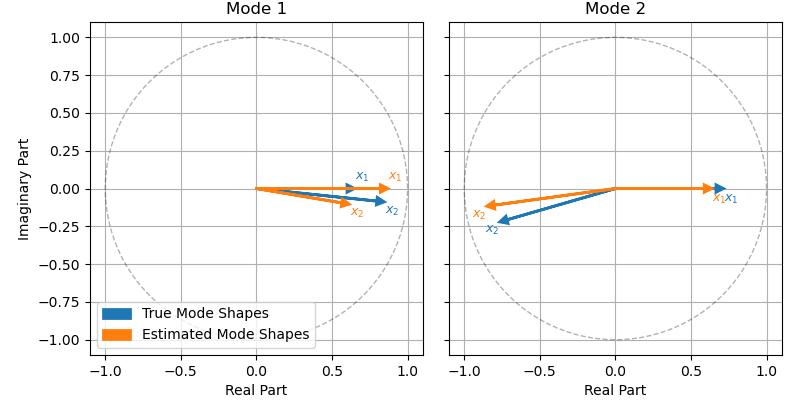

In [12]:
# Calculate estimated mode shapes
mode_shapes_estimated = calculate_modes(a_coeffs_list, pole_pairs)

# Plot true vs estimated mode shapes
plot_mode_phase_diagram(mode_shapes_non_proportional, mode_shapes_estimated)

### Parameter Estimation with Multiple Model Orders <a id='parameter-estimation-multiple'></a>

In [13]:
import pandas as pd  # import pandas library for data manipulation
from matplotlib.lines import Line2D  # import Line2D for creating custom legends


def calculate_mac(mode_a, mode_b):
    """
    Calculate the Modal Assurance Criterion (MAC) between two mode shapes.

    Parameters:
    mode_a (array): Mode shape A
    mode_b (array): Mode shape B

    Returns:
    float: Modal Assurance Criterion (MAC) between mode shapes A and B
    """
    # Phase-normalize mode shapes and enforce consistent phase difference
    mode_a = phase_normalize_mode_shapes(mode_a)
    mode_b = phase_normalize_mode_shapes(mode_b)
    mode_b = enforce_consistent_phase_difference(mode_a, mode_b)

    # Calculate numerator and denominator of MAC formula
    numerator = np.abs(mode_a.conj().T @ mode_b) ** 2
    denominator = (mode_a.conj().T @ mode_a) * (mode_b.conj().T @ mode_b)

    # Return MAC value
    return numerator / denominator


def apply_stabilization_criteria(results, freq_tol=0.01, damp_tol=0.05, mac_tol=0.95):
    """
    Apply stabilization criteria to identify stable poles across model orders

    Parameters:
    results (list): List of dictionaries containing modal parameters for each order
    freq_tol (float): Frequency tolerance (relative)
    damp_tol (float): Damping tolerance (relative)
    mac_tol (float): MAC tolerance

    Returns:
    pandas.DataFrame: DataFrame containing stabilization information
    """
    # Create a list to store all modal results from all model orders
    all_models = []

    # Process each model order result
    for result in results:
        order = result["order"]
        frequencies = result["frequencies"]
        dampings = result["dampings"]
        mode_shapes = result["mode_shapes"]

        # Add each modal result of each model order to the list
        for i in range(len(frequencies)):
            all_models.append(
                {
                    "order": order,
                    "frequency": frequencies[i],
                    "freq_Hz": frequencies[i] / (2 * np.pi),
                    "damping": dampings[i],
                    "mode_shape": np.atleast_2d(mode_shapes[:, i]).T,
                    "mode_index": i,
                    "stability": "new",
                }
            )

    # Convert to DataFrame for easier manipulation
    stabilization_dataframe = pd.DataFrame(all_models)

    # Sort by order (ascending) and frequency (ascending)
    stabilization_dataframe = stabilization_dataframe.sort_values(
        by=["order", "frequency"]
    )

    # Initialize stability flags
    stabilization_dataframe["freq_stable"] = False
    stabilization_dataframe["damp_stable"] = False
    stabilization_dataframe["mac_stable"] = False
    stabilization_dataframe["fully_stable"] = False

    # For each model order (starting from the second one)
    orders = sorted(stabilization_dataframe["order"].unique())
    for i in range(1, len(orders)):
        current_order = orders[i]
        previous_order = orders[i - 1]

        # Get results from current order
        current_order_results = stabilization_dataframe[
            stabilization_dataframe["order"] == current_order
        ]

        # Get results from previous order
        previous_order_results = stabilization_dataframe[
            stabilization_dataframe["order"] == previous_order
        ]

        # For each mode in current model order
        for idx, current_mode in current_order_results.iterrows():
            # Find closest mode in previous order by frequency
            freq_diffs = np.abs(
                current_mode["frequency"] / previous_order_results["frequency"].values
                - 1
            )
            closest_idx = np.argmin(freq_diffs)
            closest_mode = previous_order_results.iloc[closest_idx]

            # Check frequency stability
            if freq_diffs[closest_idx] < freq_tol:
                stabilization_dataframe.loc[idx, "freq_stable"] = True

            # Check damping stability
            damp_diff = np.abs(current_mode["damping"] / closest_mode["damping"] - 1)
            if damp_diff < damp_tol:
                stabilization_dataframe.loc[idx, "damp_stable"] = True

            # # Check MAC stability
            mac = calculate_mac(closest_mode["mode_shape"], current_mode["mode_shape"])
            if mac > mac_tol:
                stabilization_dataframe.loc[idx, "mac_stable"] = True

            # Check if fully stable
            if (
                stabilization_dataframe.loc[idx, "freq_stable"]
                and stabilization_dataframe.loc[idx, "damp_stable"]
                # and stabilization_dataframe.loc[idx, "mac_stable"]
            ):
                stabilization_dataframe.loc[idx, "fully_stable"] = True
                stabilization_dataframe.loc[idx, "stability"] = "stable"

    # Return the DataFrame with stabilization information
    return stabilization_dataframe

{'order': 4, 'frequencies': array([22.11508213, 63.46845613]), 'dampings': array([0.07024532, 0.08300108]), 'mode_shapes': array([[ 0.36716972-0.89959956j, -0.36691933+0.35909371j],
       [ 0.21482171-0.09878593j,  0.51550196-0.68606096j]])}


{'order': 6, 'frequencies': array([ 23.11208477,  61.18482673, 522.57469213]), 'dampings': array([0.14823172, 0.06994491, 0.0004501 ]), 'mode_shapes': array([[ 0.3980677 -0.44667162j, -0.52556482+0.40798812j,
        -0.00969933-0.00894554j],
       [ 0.59239613-0.53953072j,  0.44014064-0.60299547j,
         0.70658646+0.70750369j]])}


{'order': 8, 'frequencies': array([ 23.11176948,  61.18403035, 162.95762704, 524.86211876]), 'dampings': array([ 0.14822035,  0.06998716, -0.02771512,  0.00039255]), 'mode_shapes': array([[ 0.39810567-0.44672462j, -0.52578137+0.40810077j,
        -0.37015524+0.80910385j, -0.01142257-0.01042431j],
       [ 0.59236389-0.53949421j,  0.44005136-0.60279558j,
         0.36539088-0.27354264j,  0.70662616+0.70741808j]])}

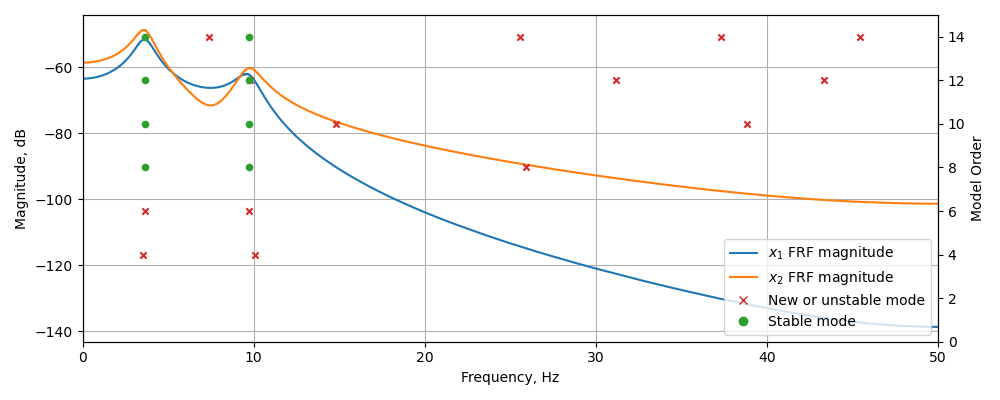

In [14]:
# Define order range for denominator polynomial
order_range = range(4, 16, 2)

# Initialize list of dictionaries to store modal parameters
modal_params_list = []

# Iterate over each order
for order in order_range:
    # Perform global curve fitting
    a_coeffs_list, b_coeffs, _, _, _, _ = grfp_curve_fit(
        symmetric_angular_frequencies, measured_frfs[:, symmetric_mask], order, order
    )

    # Estimate modal parameters from denominator coefficients
    estimated_natural_frequencies, estimated_damping_ratios, pole_pairs = extract_poles(
        b_coeffs
    )

    # Calculate estimated mode shapes
    estimated_modes = calculate_modes(a_coeffs_list, pole_pairs)

    # Store modal parameters in dictionary
    result_dict = {
        "order": order,
        "frequencies": estimated_natural_frequencies,
        "dampings": estimated_damping_ratios,
        "mode_shapes": estimated_modes,
    }
    print(result_dict)
    print("\n")
    modal_params_list.append(result_dict)

# Apply stabilization criteria to identify stable poles across model orders
stabilization_results = apply_stabilization_criteria(modal_params_list)

# Create figure with two subplots
fig, ax1 = plt.subplots(figsize=(10, 4))

# Plot FRF magnitude in the background
# Get positive frequencies only
pos_mask = frequencies >= 0
pos_freqs = frequencies[pos_mask]
# Iterate over each degree of freedom
for i in range(N_DOFS):
    # Find positive-frequency portion of the FRF
    pos_spectrum = measured_frfs[i, pos_mask]
    # Calculate magnitude
    magnitude_db = 20 * np.log10(np.abs(pos_spectrum))
    # Plot magnitude
    ax1.plot(pos_freqs, magnitude_db)

# Add axes labels and grid
ax1.set_xlabel("Frequency, Hz")
ax1.set_ylabel("Magnitude, dB")
ax1.grid(True)

# Create a second y-axis for the stability information
ax2 = ax1.twinx()

# Plot markers for different stability types
# New modes (not stable)
new_modes = stabilization_results[stabilization_results["stability"] == "new"]
ax2.scatter(new_modes["freq_Hz"], new_modes["order"], s=20, color=COLORS[3], marker="x")

# Fully stable modes
stable_modes = stabilization_results[stabilization_results["stability"] == "stable"]
ax2.scatter(
    stable_modes["freq_Hz"], stable_modes["order"], s=20, color=COLORS[2], marker="o"
)

# Add axis label, limits, and grid
ax2.set_ylabel("Model Order")
ax2.set_xlim([0, f_sampling / 2])
ax2.set_ylim([0, max(order_range) + 1])
ax2.grid(False)

# Create proxy artists for legend
x1_line = Line2D([0], [0], color=COLORS[0], label="$x_1$ FRF magnitude")
x2_line = Line2D([0], [0], color=COLORS[1], label="$x_2$ FRF magnitude")
new_mode = Line2D(
    [0],
    [0],
    color=COLORS[3],
    marker="x",
    linestyle="None",
    label="New or unstable mode",
)
stable_mode = Line2D(
    [0], [0], color=COLORS[2], marker="o", linestyle="None", label="Stable mode"
)

# Add legend
ax1.legend(handles=[x1_line, x2_line, new_mode, stable_mode], loc="lower right")

# Set layout and show plot
plt.tight_layout()
plt.show()

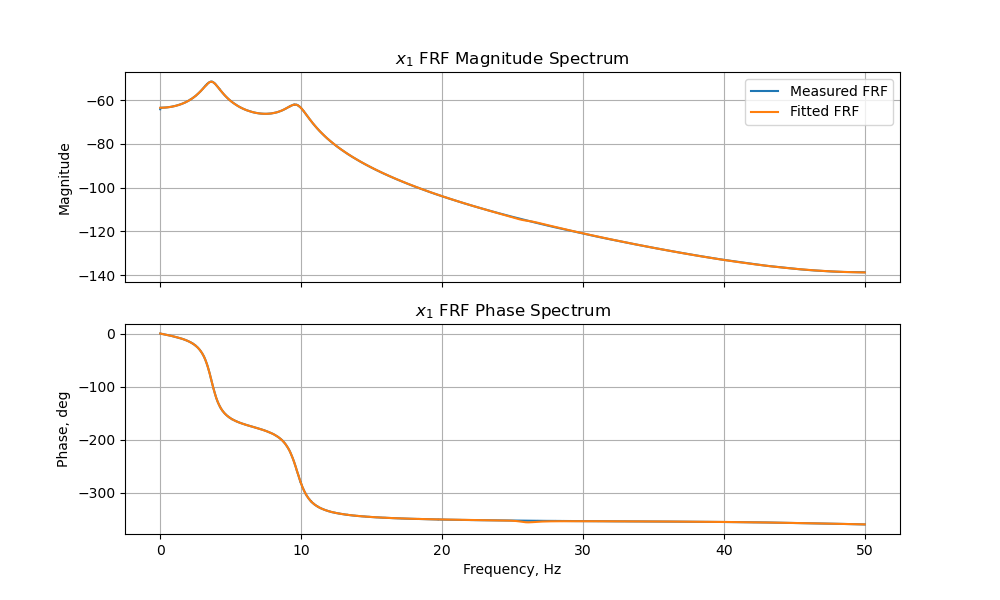

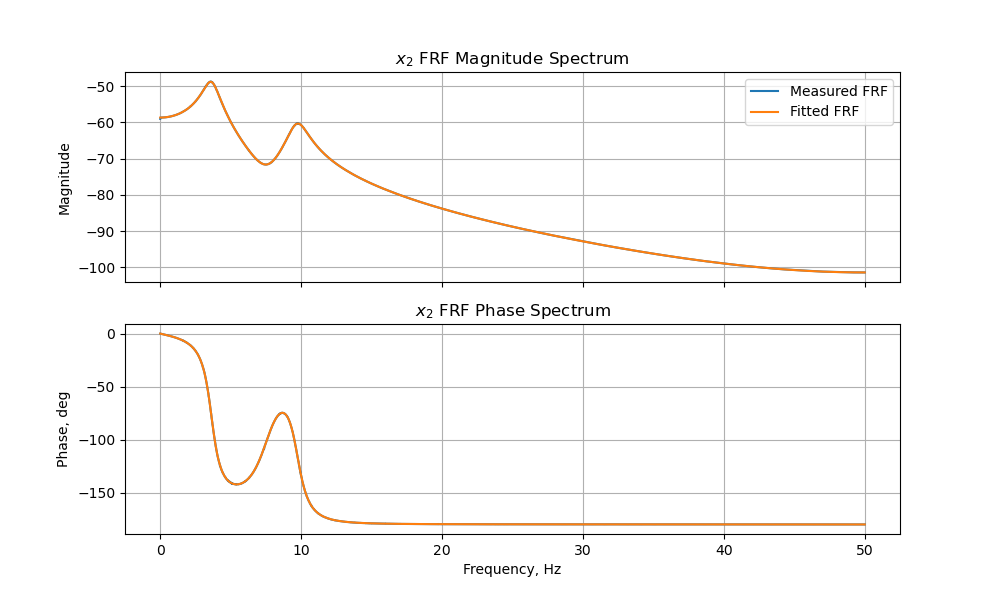

In [15]:
# Find polynomial coefficients for model order 8
model_order = 8
a_coeffs_list, b_coeffs, _, _, _, _ = grfp_curve_fit(
    symmetric_angular_frequencies,
    measured_frfs[:, symmetric_mask],
    model_order,
    model_order,
)

# Calculate fitted FRFs
fitted_frfs = calculate_fitted_frf(angular_frequencies, a_coeffs_list, b_coeffs)

# Plot original and fitted FRFs
for j in range(N_DOFS):
    _, axes = plot_spectrum(
        frequencies,
        measured_frfs[j],
        unwrap=True,
        label="Measured FRF",
    )
    plot_spectrum(
        frequencies,
        fitted_frfs[j],
        unwrap=True,
        axes=axes,
        label="Fitted FRF",
        title=f"$x_{j+1:d}$ FRF",
    )

    # Add legend and show plot
    axes[0].legend()
    plt.show()

Mode 1
True natural frequency: 23.11 rad/s
Estimated natural frequency: 23.11 rad/s
Percentage error: -0.00%
True damping ratio: 0.15
Estimated damping ratio: 0.15
Percentage error: -0.10%

Mode 2
True natural frequency: 61.19 rad/s
Estimated natural frequency: 61.18 rad/s
Percentage error: -0.01%
True damping ratio: 0.07
Estimated damping ratio: 0.07
Percentage error: 0.08%



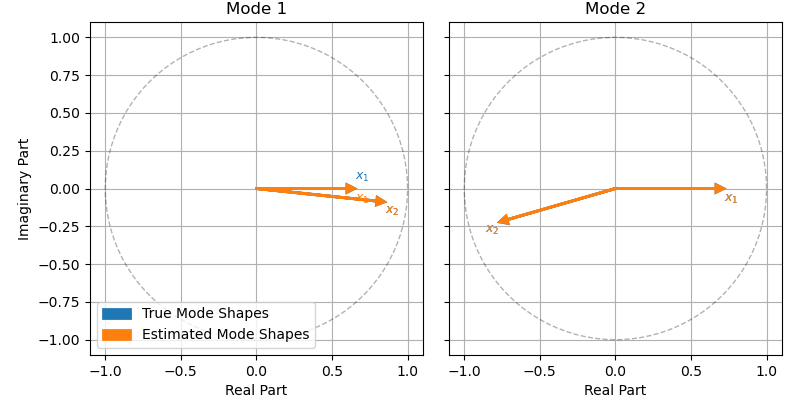

In [16]:
# Get the stable modes for the selected model order
first_stable_modes = stabilization_results[
    (stabilization_results["order"] == model_order)
    & (stabilization_results["stability"] == "stable")
]

# Initialize array to store estimated mode shapes
mode_shapes_estimated = np.zeros((N_DOFS, N_DOFS), dtype=complex)

# Compare true and estimated natural frequencies and damping ratios for each mode
for i in range(2):
    natural_frequency_estimated = first_stable_modes.iloc[i]["frequency"]
    damping_ratio_estimated = first_stable_modes.iloc[i]["damping"]
    mode_shapes_estimated[:, i] = first_stable_modes.iloc[i]["mode_shape"].flatten()
    print(f"Mode {i+1:d}")
    print(
        f"True natural frequency: {natural_frequencies_non_proportional[i]:.2f} rad/s"
    )
    print(f"Estimated natural frequency: {natural_frequency_estimated:.2f} rad/s")
    print(
        f"Percentage error: {100 * (natural_frequency_estimated/natural_frequencies_non_proportional[i] - 1):.2f}%"
    )
    print(f"True damping ratio: {damping_ratios_non_proportional[i]:.2f}")
    print(f"Estimated damping ratio: {damping_ratio_estimated:.2f}")
    print(
        f"Percentage error: {100 * (damping_ratio_estimated/damping_ratios_non_proportional[i] - 1):.2f}%\n"
    )

# Plot true vs estimated mode shapes
plot_mode_phase_diagram(mode_shapes_non_proportional, mode_shapes_estimated)